<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/12_sensitivity_diagnostics_FULL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB12_FULL — Sensibilidade Compacta e Robustez por Célula

Pipeline PPCOMP/DM — ramo `_FULL` · Borg 2019 completo por célula.

## 1. Contexto

Este notebook realiza a etapa de diagnóstico de sensibilidade do ramo `_FULL`, após a consolidação dos cenários no NB10_FULL e a seleção dos modelos tabulares no NB11_FULL.

No pipeline `_FULL`, a unidade experimental é a célula Borg (`cell_id`). Cada célula representa uma réplica operacional independente do Borg 2019 completo, com distribuição própria de eventos, falhas, episódios, estados e classe positiva. Por isso, nenhuma etapa deste notebook concatena as oito células como se fossem uma única série temporal.

O NB12_FULL avalia se as decisões centrais herdadas do NB10_FULL/NB11_FULL permanecem estáveis quando se aplicam variações moderadas de cenário. A etapa é deliberadamente compacta: ela não reabre uma busca ampla de modelos, não substitui o NB11_FULL e não redefine o problema supervisionado. Seu papel é testar robustez e identificar células que exigem revisão localizada.

## 2. Relação com o NB10_FULL e o NB11_FULL

O NB10_FULL fornece, por célula, os cenários de limiar, estados, episódios e decisões de sensibilidade. O NB11_FULL seleciona, também por célula, a referência supervisionada principal e o modelo vencedor para cada cenário modelável.

O NB12_FULL opera sobre esses artefatos já definidos. Assim:

1. o NB10_FULL define quais cenários existem e quais devem ser avaliados como sensibilidade;
2. o NB11_FULL define o modelo vencedor e a referência supervisionada por célula;
3. o NB12_FULL reaplica o vencedor do NB11_FULL nos cenários de sensibilidade elegíveis;
4. a comparação é feita sempre contra a referência local da própria célula;
5. a decisão final é de confirmação, revisão localizada ou manutenção descritiva.

## 3. Objetivo

O objetivo do NB12_FULL é verificar a robustez das decisões centrais do pipeline tabular `_FULL` sob variações compactas de cenário, preservando a unidade experimental `cell_id`.

Especificamente, o notebook deve:

1. carregar, por célula, os cenários produzidos pelo NB10_FULL;
2. recuperar a referência e o modelo vencedor definidos no NB11_FULL;
3. aplicar o vencedor local aos cenários supervisionados de sensibilidade;
4. preservar o gate de modelabilidade para não forçar células ou cenários sem suporte mínimo;
5. manter `train_p99` e `global_m2s` como diagnósticos descritivos;
6. avaliar `train_p95` como cláusula de revisão, não como substituição automática;
7. comparar cada sensibilidade contra a referência NB11_FULL da própria célula;
8. produzir sumários por célula e agregados rastreáveis;
9. registrar se alguma célula exige revisão metodológica localizada.

## 4. Papel no pipeline `_FULL`

O NB12_FULL é uma etapa de diagnóstico de robustez, não uma etapa de seleção global de novo cenário.

A pergunta metodológica central não é “qual cenário vence no conjunto completo?”, mas sim:

> As decisões do NB11_FULL permanecem defensáveis quando a formulação é submetida a variações moderadas de limiar, persistência, horizonte e janela, célula por célula?

Desse modo, o notebook deve produzir três tipos de evidência:

1. **confirmação local**, quando a referência NB11_FULL permanece competitiva;
2. **revisão localizada**, quando uma sensibilidade, especialmente `train_p95`, supera a referência local por margem relevante;
3. **limitação descritiva**, quando a célula ou cenário não possui suporte supervisionado suficiente.

Essa leitura preserva a filosofia do ramo `_FULL`: avaliar a robustez do cenário principal por célula, tomando o protótipo Kaggle ajustado como etapa de desenvolvimento metodológico que antecede o FULL, sem hierarquia de substituição.

## 5. Unidade experimental e escopo por célula

A célula Borg é a unidade experimental deste notebook.

Consequentemente:

1. as métricas são calculadas por `cell_id`;
2. a modelabilidade é avaliada por célula e cenário;
3. o modelo vencedor é escolhido preferencialmente dentro da própria célula;
4. o fallback para vencedor global só é permitido quando a célula não possui vencedor local válido;
5. a comparação `train_p95` versus referência NB11_FULL é sempre local;
6. as saídas são gravadas em `cell_<id>` e depois consolidadas em `aggregate`;
7. a leitura agregada deve preservar a heterogeneidade entre células.

A concatenação das oito células como uma única série temporal é proibida, pois misturaria regimes operacionais distintos e quebraria a interpretação experimental do `_FULL`.

## 6. Cenários avaliados

O NB12_FULL trabalha com os cenários de sensibilidade herdados do NB10_FULL.

A política metodológica é:

1. `train_m2s`: referência principal herdada do NB11_FULL;
2. `train_p95`: cenário de revisão, usado para testar se um limiar percentílico menos conservador melhora a antecipação;
3. `train_p99`: cenário descritivo/histórico, sem modelagem supervisionada;
4. `global_m2s`: cenário descritivo/histórico, sem modelagem supervisionada.

Assim, `train_p99` e `global_m2s` não devem aparecer em métricas TSCV, fixed split ou sumários supervisionados. Eles podem aparecer apenas nos artefatos descritivos de episódios, estados e distribuição de rótulos.

## 7. Entradas esperadas

As entradas principais são os artefatos do NB10_FULL e NB11_FULL:

1. `04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics/cell_<id>/10_FULL_scenario_decisions_cell_<id>.csv`;
2. `04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics/cell_<id>/10_FULL_scenario_series_states_cell_<id>.parquet`;
3. `04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics/cell_<id>/10_FULL_scenario_episodes_cell_<id>.parquet`;
4. `04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate/11_FULL_winner_model.json`;
5. `04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate/11_FULL_metrics_summary_by_cell.csv`;
6. `04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate/11_FULL_modelability_by_cell_scenario.csv`.

Essas entradas devem conter `cell_id`, `scenario_label`, informações de modelabilidade, corte herdado e os campos necessários para reconstruir ou validar o alvo supervisionado.

## 8. Saídas esperadas

As saídas devem ser gravadas exclusivamente em:

`04-reports/99_FULL_downstream/12_FULL_sensitivity/`

com subpastas:

1. `cell_a`;
2. `cell_b`;
3. `cell_c`;
4. `cell_d`;
5. `cell_e`;
6. `cell_f`;
7. `cell_g`;
8. `cell_h`;
9. `aggregate`.

As principais saídas esperadas são:

1. `12_FULL_nb12_summary.json`;
2. `12_FULL_sensitivity_summary_by_cell.csv`;
3. `12_FULL_sensitivity_aggregate.csv`;
4. `12_FULL_sensitivity_metrics_tscv_by_cell.csv`;
5. `12_FULL_sensitivity_metrics_fixed_split_by_cell.csv`;
6. `12_FULL_sensitivity_descriptive_by_cell.csv`;
7. `12_FULL_train_p95_review_by_cell.csv`;
8. `12_FULL_modelability_by_cell_scenario.csv`;
9. `12_FULL_winner_context_by_cell.csv`;
10. `12_FULL_execution_errors_by_cell.csv`;
11. `12_FULL_scores_sensitivity_fixed_by_cell.parquet`;
12. `12_FULL_pilot_validation_summary.csv`;
13. `12_FULL_delta_vs_canonical.csv`;
14. `12_FULL_diff_summary.csv`;
15. `12_FULL_diff_vs_canonical.patch`;
16. `12_FULL_nbdiff_vs_canonical.txt`;
17. `12_FULL_artifact_manifest_sha256.csv`;
18. figuras agregadas em `aggregate/figures/`.

Nenhuma saída deste notebook deve usar nome sem o prefixo `12_FULL_` ou confundível com a trilha Kaggle de referência.

## 9. Herança do corte temporal

O corte treino/teste não é rederivado neste notebook.

O NB12_FULL deve herdar `train_cutoff_idx` e `train_cutoff_bucket_id` dos artefatos upstream. Caso esses campos estejam ausentes, a execução deve falhar de forma explícita, pois recalcular o corte por fração local poderia deslocar a fronteira temporal e gerar contradição com NB04_FULL, NB06_FULL, NB10_FULL e NB11_FULL.

O corte fixo 80/20 permanece como análise complementar, mas sua fronteira é herdada. A validação temporal por partições progressivas permanece como evidência principal de desempenho supervisionado.

## 10. Tratamento do alvo e da borda de horizonte

A tarefa supervisionada do pipeline é prospectiva: uma instância é positiva quando existe entrada em `DURING` dentro do horizonte futuro `H`.

Por definição, as últimas `H` janelas de cada série não possuem horizonte futuro completo. Portanto, essas linhas não devem ser tratadas como anomalia; elas devem ser removidas antes da coerção binária do alvo.

Quando o upstream fornecer colunas como `eligible_supervised`, `has_complete_horizon` ou equivalentes, o NB12_FULL deve respeitá-las. Quando essas colunas não existirem, o notebook deve derivar `has_complete_horizon_nb12` por posição temporal, removendo as últimas `H` janelas do cenário.

Após essa remoção, qualquer alvo não-finito remanescente deve ser tratado como erro real de consistência. Essa guarda impede que `NaN` de meio de série seja mascarado como valor negativo ou positivo arbitrário.

## 11. Parser de `scenario_label`

O parser de `scenario_label` deve reconhecer labels no formato real do ramo `_FULL`:

`cell_<id>_W<W>_K<K>_H<H>_<threshold>_P<P>`

Exemplos válidos:

1. `cell_a_W5_K24_H12_train_m2s_P1`;
2. `cell_g_W5_K24_H12_train_p95_P1`;
3. `cell_h_W10_K12_H6_train_p99_P2`.

A extração correta de `W`, `K`, `H`, `P` e `threshold_family` é necessária para:

1. selecionar apenas cenários supervisionados permitidos;
2. manter `train_p99` e `global_m2s` como descritivos;
3. localizar o par comparável `train_p95` versus `train_m2s`;
4. produzir agregações interpretáveis por cenário;
5. evitar que labels fora do padrão sejam aceitos silenciosamente como `unknown`.

Como defesa-em-profundidade, a família do limiar também deve ser inferida a partir do `scenario_label` cru quando o parser formal falhar.

## 12. Gate de modelabilidade

O gate de modelabilidade é parte da metodologia, não uma falha operacional.

Um cenário só deve ser modelado quando houver suporte mínimo de positivos em treino e teste. Cenários sem suporte suficiente devem ser mantidos como descritivos ou registrados como skip controlado por `modelability_gate`.

Essa regra é especialmente importante no ramo `_FULL`, pois algumas células apresentam regimes raros, com poucos episódios ou poucos positivos supervisionados. Forçar esses casos em validação supervisionada produziria métricas instáveis e metodologicamente frágeis.

## 13. Modelos e protocolo de avaliação

O NB12_FULL não executa nova busca ampla de modelos.

Para cada célula e cenário elegível, o notebook utiliza preferencialmente o modelo vencedor definido pelo NB11_FULL para a própria célula. Quando esse vencedor local não está disponível, admite-se fallback controlado para o vencedor global do NB11_FULL, com registro explícito.

A avaliação supervisionada deve reportar:

1. métricas por fold em `TimeSeriesSplit`;
2. média e desvio-padrão por cenário;
3. métricas no corte fixo herdado;
4. comparação contra a referência NB11_FULL local;
5. identificação de ganhos ou perdas em F1 TSCV.

O F1 TSCV é a métrica principal para acionar revisão, pois combina precisão e recall sob validação temporal, mantendo coerência com a interpretação adotada desde o NB11_FULL.

## 14. Cláusula de revisão `train_p95`

O cenário `train_p95` é avaliado como cláusula de revisão.

A revisão é acionada quando `train_p95` supera a referência NB11_FULL da mesma célula por mais de 5 pontos percentuais de F1 TSCV.

Essa regra não significa troca automática de cenário global. Ela indica que, naquela célula, a escolha herdada merece reavaliação metodológica localizada.

A comparação deve respeitar:

1. mesma célula;
2. mesmo conjunto estrutural de parâmetros quando possível (`W`, `K`, `H`, `P`);
3. mesmo protocolo de avaliação;
4. referência NB11_FULL local;
5. diferença expressa em pontos percentuais de F1.

## 15. Agregação e leitura esperada

A agregação do NB12_FULL deve preservar duas leituras:

1. **by_cell**, para decisões metodológicas por célula;
2. **aggregate**, para síntese do comportamento do ramo `_FULL`.

A leitura agregada não deve ocultar a heterogeneidade. Um cenário pode ser forte em uma célula, neutro em outra e inviável em outra. Essa variação é parte do resultado científico do `_FULL`, pois revela a mudança de regime entre células do Borg completo.

Para tabelas posteriores da dissertação, é recomendável produzir também uma visão por `base_scenario`, removendo o prefixo `cell_<id>_` do `scenario_label`. Essa visão é útil para comparação cross-cell, mas não substitui a decisão por célula.

## 16. Diferenças em relação ao NB12 do protótipo Kaggle ajustado

Em relação ao NB12 da trilha Kaggle, o NB12_FULL altera a casca de orquestração, não a lógica científica principal.

As diferenças são:

1. entrada baseada em artefatos `NB10_FULL` e `NB11_FULL`, não no diretório da trilha Kaggle de referência;
2. execução segmentada por `cell_id`;
3. preservação da célula como unidade experimental independente;
4. uso do vencedor NB11_FULL por célula, com fallback controlado;
5. gate de modelabilidade aplicado por célula e cenário;
6. corte treino/teste herdado, nunca rederivado por fração;
7. `train_p99` e `global_m2s` tratados como descritivos;
8. revisão `train_p95` feita localmente por célula;
9. saídas com prefixo obrigatório `12_FULL_`;
10. consolidação em `cell_<id>` e `aggregate`.

## 17. Observações metodológicas iniciais

Esta etapa deve evitar conclusões globais apressadas.

Assim:

1. melhora em `train_p95` numa célula não implica substituição global do cenário principal;
2. ausência de cenário modelável não implica erro, se decorrer do gate de suporte mínimo;
3. `train_p99` e `global_m2s` devem permanecer fora da modelagem supervisionada;
4. o corte herdado é uma trava de rastreabilidade;
5. a interpretação principal é a estabilidade ou instabilidade das decisões por célula;
6. os resultados devem ser usados como diagnóstico para NB13_FULL, NB14_FULL, NB15_FULL e NB16_FULL.

## Nota metodológica — NB12_FULL executado

Este notebook é deliberadamente compacto: ele **não repete o NB11_FULL** e **não abre novo grid search**. Ele executa apenas o vencedor do NB11_FULL nos cenários `sensitivity_only` elegíveis por célula.

Correções incorporadas a partir do aprendizado recente do NB11_FULL:

- Células descritivas não são forçadas no pipeline supervisionado.
- O macro agregado separa leitura geral de leitura `modelable_only`.
- O corte treino/teste é herdado; ausência de `train_cutoff_idx` é erro metodológico, não oportunidade para recalcular por fração.
- A comparação `train_p95` contra `train_m2s` é feita por célula, e o resumo agregado registra se alguma célula acionou revisão.


NB12_FULL iniciado em: 2026-07-04 18:47:14
Mounted at /content/drive
[Bootstrap] Atualizando repositório (git pull)...
DRIVE_ROOT       : /content/drive/MyDrive/Mestrado
STAGE10_DIR      : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics
STAGE11_AGG_DIR  : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate
STAGE12_DIR      : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/12_FULL_sensitivity
AGGREGATE_DIR    : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/12_FULL_sensitivity/aggregate
ACTIVE_CELLS     : ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
winner_global:
{
  "cell_id": "g",
  "scenario_label": "cell_g_W5_K24_H12_train_m2s_P1",
  "feature_set": "temporal_core",
  "model": "hist_gradient_boosting",
  "f1_tscv_mean": 0.633126396741871,
  "f1_tscv_std": 0.12896706890992332,
  "recall_tscv_mean": 0.6697141621563212,
  "recall_tscv_std": 0.11241114808846715,
  "precision_

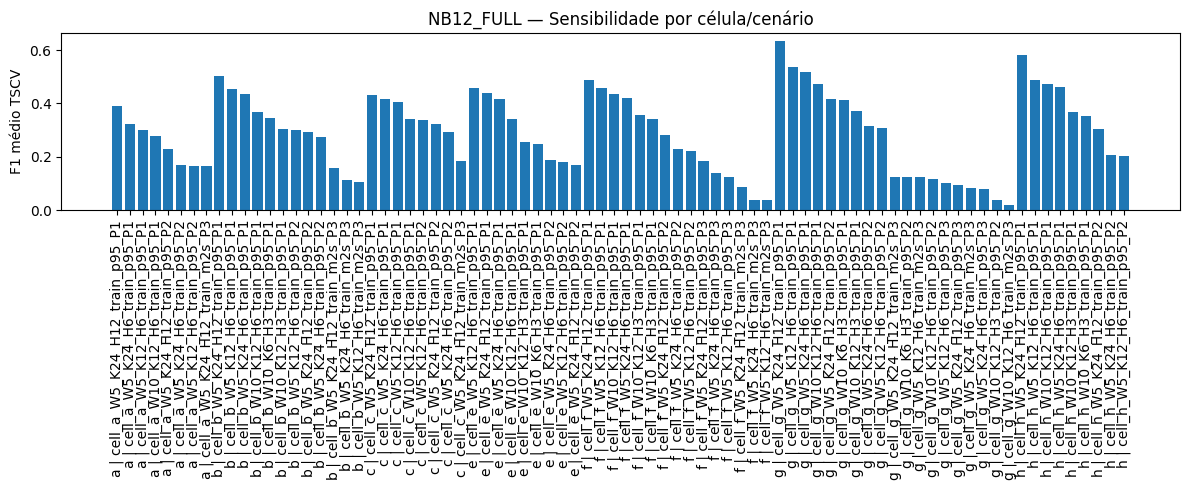

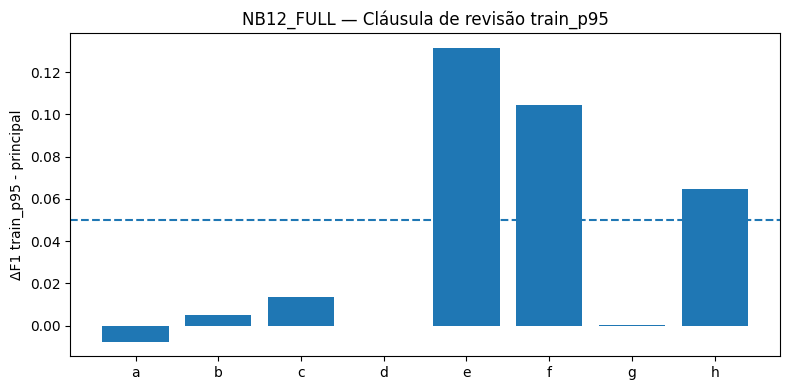

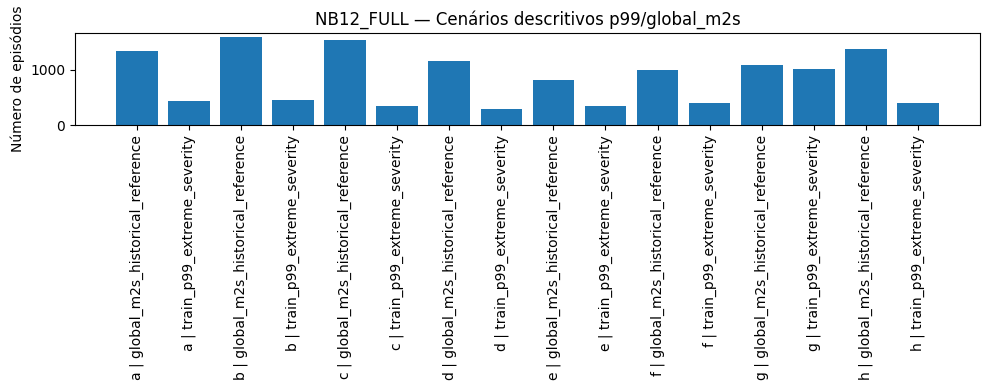


=== NB12_FULL — arquivos aggregate gerados ===


,artifact,path,exists
0,metrics_tscv_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
1,metrics_fixed_split_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
2,sensitivity_summary_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
3,sensitivity_aggregate,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
4,sensitivity_descriptive_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
5,modelability_by_cell_scenario,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
6,train_p95_review_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
7,winner_context_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
8,execution_errors_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
9,scores_sensitivity_fixed_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True



=== NB12_FULL — vencedor/contexto por célula ===


,cell_id,scenario_label,feature_set,model,features,f1_tscv_mean,selection_scope,fallback_used,fallback_reason,source
0,a,cell_a_W5_K24_H12_train_m2s_P1,temporal_core,logistic_regression,"[fail_rate, n_events, n_failed, n_machines, n_...",0.398273,cell_winner_modelable_only,False,,11_FULL_metrics_summary_by_cell.csv
1,b,cell_b_W5_K24_H12_train_m2s_P1,temporal_core,hist_gradient_boosting,"[fail_rate, n_events, n_failed, n_machines, n_...",0.496409,cell_winner_modelable_only,False,,11_FULL_metrics_summary_by_cell.csv
2,c,cell_c_W5_K24_H6_train_m2s_P1,temporal_core,hist_gradient_boosting,"[fail_rate, n_events, n_failed, n_machines, n_...",0.401552,cell_winner_modelable_only,False,,11_FULL_metrics_summary_by_cell.csv
3,d,cell_d_W5_K24_H12_train_m2s_P2,raw_7,logistic_regression,"[fail_rate, n_events, n_failed, n_machines, n_...",0.426165,cell_winner_all_status_fallback,False,,11_FULL_metrics_summary_by_cell.csv
4,e,cell_e_W5_K12_H6_train_m2s_P1,temporal_core,hist_gradient_boosting,"[fail_rate, n_events, n_failed, n_machines, n_...",0.326230,cell_winner_modelable_only,False,,11_FULL_metrics_summary_by_cell.csv
5,f,cell_f_W5_K24_H12_train_m2s_P1,temporal_core,logistic_regression,"[fail_rate, n_events, n_failed, n_machines, n_...",0.385456,cell_winner_modelable_only,False,,11_FULL_metrics_summary_by_cell.csv
6,g,cell_g_W5_K24_H12_train_m2s_P1,temporal_core,hist_gradient_boosting,"[fail_rate, n_events, n_failed, n_machines, n_...",0.633126,cell_winner_modelable_only,False,,11_FULL_metrics_summary_by_cell.csv
7,h,cell_h_W5_K24_H12_train_m2s_P1,temporal_core,logistic_regression,"[fail_rate, n_events, n_failed, n_machines, n_...",0.516797,cell_winner_modelable_only,False,,11_FULL_metrics_summary_by_cell.csv



=== NB12_FULL — modelabilidade por célula/cenário ===


...


=== NB12_FULL — validações de piloto ===


,check_name,status,value,detail
0,active_cells_non_empty,OK,8,"['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']"
1,nb11_winner_present,OK,1,/content/drive/MyDrive/Mestrado/04-reports/99_...
2,modelability_table_generated,OK,122,Tabela NB12_FULL de modelabilidade por célula/...
3,model_candidate_coverage,OK,80/122 (65.6%),Cobertura mínima esperada: 50%. Detecta aborto...
4,n_cells_with_modelable_sensitivity,OK,7,Células com ao menos um cenário de sensibilida...
5,n_cells_without_modelable_sensitivity,OK,1,Células que ficam apenas descritivas no NB12_F...
6,no_train_p99_supervised_metrics,OK,0,Cenários train_p99 devem permanecer descritivo...
7,train_p95_review_resolved_when_candidate_exists,OK,0,"Se há train_p95 nos candidatos, o review não p..."
8,aggregate_scopes_present,OK,"all_cells_including_descriptive,modelable_only",Escopos esperados: ['all_cells_including_descr...
9,no_canonical_output_prefix,OK,12_FULL_*,Todos os artefatos do NB12_FULL usam prefixo 1...



=== NB12_FULL — sumário final ===
{
  "notebook": "NB12_FULL_sensitivity_diagnostics",
  "executed_at": "2026-07-04 19:02:29",
  "active_cells": [
    "a",
    "b",
    "c",
    "d",
    "e",
    "f",
    "g",
    "h"
  ],
  "stage12_dir": "/content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/12_FULL_sensitivity",
  "upstream_stage10_dir": "/content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics",
  "upstream_stage11_aggregate_dir": "/content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate",
  "objective": "Verificar estabilidade das escolhas do NB10_FULL/NB11_FULL sob sensibilidade compacta por célula.",
  "policy": {
    "no_nb11_repetition": true,
    "no_wide_grid_search": true,
    "model_execution": "apenas vencedor do NB11_FULL por célula nos cenários sensitivity_only elegíveis",
    "p99_policy": "descriptive_only_no_model_execution",
    "global_m2s_policy": "historical_reference_no_model_exec

,relative_path,size_bytes,sha256
79,cell_g/12_FULL_execution_errors_cell_g.csv,952,7b8681a70e2229e68bce2f5c361fd20f560c71c98b38a6...
80,cell_g/12_FULL_modelability_by_scenario_cell_g...,4524,25dd20692702e1b5d79b48abf736494b230264d6d9f68d...
81,cell_g/12_FULL_scenario_selection_cell_g.json,2312,af04c932144ee8e1036a4bd9ebb14917fbf8c2c7b5b61a...
82,cell_g/12_FULL_scores_sensitivity_fixed_cell_g...,161923,8ce1717500721423bdb8639633e957a65eb9337a2d32f4...
83,cell_g/12_FULL_sensitivity_descriptive_cell_g.csv,8923,a540096196e3f72877e3ada770da4de73f1d60e964c6e9...
84,cell_g/12_FULL_sensitivity_metrics_fixed_split...,10102,edf51ee5b4d5044d615bf76ce421bf790ad5ed1fdbb12e...
85,cell_g/12_FULL_sensitivity_metrics_tscv_cell_g...,45450,e3e8e6352c37435e1a9d3b26812378d85611c630bc65ac...
86,cell_g/12_FULL_sensitivity_summary_cell_g.csv,7577,5ba1d5fb57c6f3d1d5a7d9cab2ea24faef3adbe77d4331...
87,cell_g/12_FULL_train_p95_review_cell_g.json,539,991ecba4246749176921530890be6f29f7acc0009f4832...
88,cell_g/12_FULL_winner_context_cell_g.json,617,d5451d36cda708dbdea5acb126d40430eb8c61c969ffbd...


NB12_FULL finalizado em: 2026-07-04 19:02:30


In [ ]:

# ============================================================
# NB12_FULL — Sensibilidade Compacta e Robustez por célula
# Pipeline PPCOMP/DM — ramo _FULL
#
# Versão proposta:
#   1. Iteração por cell_id.
#   2. Consumo dos artefatos do NB10_FULL e NB11_FULL.
#   3. Vencedor preferencial por célula, fallback global auditável.
#   4. Gate modelável/descritiva por cenário, com positivos train/test no corte herdado.
#   5. Corte treino/teste herdado de train_cutoff_idx/train_cutoff_bucket_id.
#   6. p99 e global_m2s descritivos, sem execução supervisionada.
#   7. Saídas 12_FULL_* por célula e aggregate.
# ============================================================

# ============================================================
# 0. Imports e configuração geral
# ============================================================

import os
import re
import json
import math
import shutil
import hashlib
import subprocess
import importlib
import warnings
import difflib
import traceback
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS_TSCV = 5
FIXED_TRAIN_FRAC_REFERENCE = 0.80  # referência para validação leve; nunca usada para rederivar corte
DEFAULT_THRESHOLD = 0.50
REVIEW_DELTA_F1 = 0.05
MIN_MODEL_CANDIDATE_COVERAGE = 0.50
MIN_TRAIN_POSITIVES_FOR_MODELING = 30
MIN_TEST_POSITIVES_FOR_MODELING = 30
MIN_TSCV_SPLITS = 2

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

print("NB12_FULL iniciado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


# ============================================================
# 1. Bootstrap, caminhos oficiais _FULL e travas de herança
# ============================================================

if not Path("/content/drive/MyDrive").exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível montar o Google Drive automaticamente.")
        print("[Bootstrap] Detalhe:", e)
else:
    print("[Bootstrap] Google Drive já montado.")

MYDRIVE_ROOT = Path("/content/drive/MyDrive")
DRIVE_ROOT = MYDRIVE_ROOT / "Mestrado"
REPO_DIR = DRIVE_ROOT / "PPCOMP_DM"
NOTEBOOKS_DIR = MYDRIVE_ROOT / "Colab Notebooks"
CANONICAL_NOTEBOOK = NOTEBOOKS_DIR / "12_sensitivity_diagnostics.ipynb"
FULL_NOTEBOOK = NOTEBOOKS_DIR / "12_sensitivity_diagnostics_FULL.ipynb"
GITHUB_REPO = "https://github.com/sergiocostaifes/PPCOMP_DM.git"

# O repositório não é exigido para a execução, mas é útil para diff e rastreabilidade.
if REPO_DIR.exists():
    try:
        print("[Bootstrap] Atualizando repositório (git pull)...")
        subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=False)
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível atualizar via git pull:", e)
    try:
        os.chdir(str(REPO_DIR))
        if str(REPO_DIR) not in os.sys.path:
            os.sys.path.insert(0, str(REPO_DIR))
        importlib.invalidate_caches()
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível usar REPO_DIR como CWD:", e)

FULL_CELLS = list("abcdefgh")
ACTIVE_CELLS = FULL_CELLS[:]  # Para piloto: ACTIVE_CELLS = ["a"]
# ACTIVE_CELLS = ["a"]

FULL_MODEL_FACING_PARQUET = (
    DRIVE_ROOT
    / "02-datasets"
    / "99-full"
    / "03-model-facing"
    / "window_5min_series_allcells_model_facing_000000000000.parquet"
)
CANONICAL_WINDOW_5MIN_SERIES = DRIVE_ROOT / "02-datasets" / "03-features" / "window_5min_series.parquet"

FULL_REPORTS_DIR = DRIVE_ROOT / "04-reports" / "99_FULL_downstream"
STAGE10_DIR = FULL_REPORTS_DIR / "10_FULL_threshold_diagnostics"
STAGE11_DIR = FULL_REPORTS_DIR / "11_FULL_model_baselines"
STAGE11_AGG_DIR = STAGE11_DIR / "aggregate"
STAGE12_DIR = FULL_REPORTS_DIR / "12_FULL_sensitivity"
AGGREGATE_DIR = STAGE12_DIR / "aggregate"
FIGURES_DIR = AGGREGATE_DIR / "figures"
FIGURES_BY_CELL_DIR = AGGREGATE_DIR / "figures_by_cell"

for p in [FULL_REPORTS_DIR, STAGE12_DIR, AGGREGATE_DIR, FIGURES_DIR, FIGURES_BY_CELL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("DRIVE_ROOT       :", DRIVE_ROOT)
print("STAGE10_DIR      :", STAGE10_DIR)
print("STAGE11_AGG_DIR  :", STAGE11_AGG_DIR)
print("STAGE12_DIR      :", STAGE12_DIR)
print("AGGREGATE_DIR    :", AGGREGATE_DIR)
print("ACTIVE_CELLS     :", ACTIVE_CELLS)

assert "03-features" not in str(FULL_REPORTS_DIR), "FULL_REPORTS_DIR não pode apontar para 03-features."
assert FULL_MODEL_FACING_PARQUET != CANONICAL_WINDOW_5MIN_SERIES, "Entrada FULL não pode ser a série do protótipo Kaggle ajustado."
assert STAGE10_DIR.exists(), f"Artefatos NB10_FULL não encontrados: {STAGE10_DIR}"
assert STAGE11_AGG_DIR.exists(), f"Aggregate do NB11_FULL não encontrado: {STAGE11_AGG_DIR}"

CANONICAL_TEMPORAL_CORE = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_FAIL_count",
    "event_LOST_count",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]
temporal_core = CANONICAL_TEMPORAL_CORE[:]
assert len(temporal_core) == 14
assert temporal_core == CANONICAL_TEMPORAL_CORE

if FULL_MODEL_FACING_PARQUET.exists():
    try:
        df_cells_check = pd.read_parquet(FULL_MODEL_FACING_PARQUET, columns=["cell_id"])
        observed_cells = sorted(df_cells_check["cell_id"].dropna().astype(str).unique().tolist())
        assert observed_cells == FULL_CELLS, f"cell_id inesperado no Parquet FULL: {observed_cells}"
    except Exception as e:
        print("[NB12_FULL] Aviso: não foi possível checar cell_id no Parquet FULL:", e)
else:
    print(f"[NB12_FULL] Aviso: Parquet model-facing FULL não encontrado para checagem leve: {FULL_MODEL_FACING_PARQUET}")

RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")


def log(msg: str) -> None:
    print(f"[NB12_FULL_sensitivity] {msg}")


# ============================================================
# 2. Utilidades gerais
# ============================================================

def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(json_ready(obj), f, ensure_ascii=False, indent=2)


def read_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def json_ready(obj):
    """Converte objetos NumPy/Pandas/Path para JSON seguro."""
    if isinstance(obj, dict):
        return {str(k): json_ready(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [json_ready(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        val = float(obj)
        return None if np.isnan(val) else val
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    try:
        if pd.isna(obj):
            return None
    except Exception:
        pass
    return obj


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


def build_artifact_manifest(root_dir: Path, out_file: Path) -> pd.DataFrame:
    rows = []
    for p in sorted(root_dir.rglob("*")):
        if not p.is_file():
            continue
        if p == out_file:
            continue
        rows.append({
            "relative_path": str(p.relative_to(root_dir)).replace("\\", "/"),
            "size_bytes": int(p.stat().st_size),
            "sha256": sha256_file(p),
        })
    df = pd.DataFrame(rows)
    df.to_csv(out_file, index=False, encoding="utf-8")
    return df


def save_csv(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8")


def save_parquet(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)


# Esquemas mínimos esperados para CSVs por célula que podem ficar sem linhas.
# Objetivo: permitir leitura posterior com pd.read_csv mesmo quando uma célula
# não possui cenários supervisionados modeláveis, como ocorre em cell_d.
NB12_CELL_TSCV_COLUMNS = [
    "cell_id", "scenario_label", "W", "K", "H", "P", "threshold_kind", "threshold_family",
    "train_cutoff_idx", "train_cutoff_bucket_id", "cutoff_source", "n_supervised_rows",
    "n_train", "n_test", "n_positivos_train", "n_positivos_test", "positive_rate_train",
    "positive_rate_test", "status_modelagem", "is_modelable", "modelability_reason",
    "validation", "fold", "feature_set", "model", "winner_selection_scope", "winner_fallback_used",
    "nb11_reference_f1_tscv_mean", "n", "positive_rate", "threshold", "accuracy",
    "precision", "recall", "f1", "roc_auc", "average_precision", "brier", "tn", "fp",
    "fn", "tp", "false_alerts", "false_alerts_per_day",
]

NB12_CELL_FIXED_COLUMNS = [
    "cell_id", "scenario_label", "W", "K", "H", "P", "threshold_kind", "threshold_family",
    "train_cutoff_idx", "train_cutoff_bucket_id", "cutoff_source", "n_supervised_rows",
    "n_train", "n_test", "n_positivos_train", "n_positivos_test", "positive_rate_train",
    "positive_rate_test", "status_modelagem", "is_modelable", "modelability_reason",
    "validation", "feature_set", "model", "winner_selection_scope", "winner_fallback_used",
    "nb11_reference_f1_tscv_mean", "n", "positive_rate", "threshold", "accuracy",
    "precision", "recall", "f1", "roc_auc", "average_precision", "brier", "tn", "fp",
    "fn", "tp", "false_alerts", "false_alerts_per_day",
]

NB12_CELL_SUMMARY_COLUMNS = [
    "cell_id", "scenario_label", "W", "K", "H", "P", "threshold_kind", "threshold_family",
    "feature_set", "model", "status_modelagem", "is_modelable", "winner_selection_scope",
    "winner_fallback_used", "n_folds_valid", "n_rows_test_total", "positive_rate_test_mean",
    "f1_tscv_mean", "f1_tscv_std", "recall_tscv_mean", "precision_tscv_mean",
    "roc_auc_tscv_mean", "average_precision_tscv_mean", "brier_tscv_mean",
    "false_alerts_per_day_mean", "nb11_reference_f1_tscv_mean", "n_positivos_train",
    "n_positivos_test", "delta_f1_vs_nb11_cell_reference",
]


def save_csv_with_header_when_empty(df: pd.DataFrame, path: Path, expected_columns: list) -> None:
    """Grava CSV normal; se vazio, grava 0 linhas com cabeçalho esperado."""
    if df is None:
        df = pd.DataFrame()
    if df.empty:
        df = pd.DataFrame(columns=expected_columns)
    save_csv(df, path)


def find_existing(paths, required=True, label="arquivo"):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    if required:
        raise FileNotFoundError(f"{label} não encontrado em: " + " | ".join(str(p) for p in paths))
    return None


# ============================================================
# 3. Carregamento dos artefatos NB11_FULL aggregate
# ============================================================

PATH_NB11_WINNER = find_existing([STAGE11_AGG_DIR / "11_FULL_winner_model.json"], required=True, label="winner NB11_FULL")
PATH_NB11_SUMMARY = find_existing([STAGE11_AGG_DIR / "11_FULL_nb11_summary.json"], required=False, label="summary NB11_FULL")
PATH_NB11_METRICS_SUMMARY = find_existing([STAGE11_AGG_DIR / "11_FULL_metrics_summary_by_cell.csv"], required=True, label="metrics NB11_FULL")
PATH_NB11_BASELINES_SUMMARY = find_existing([STAGE11_AGG_DIR / "11_FULL_baselines_summary_by_cell.csv"], required=False, label="baselines NB11_FULL")
PATH_NB11_MODELABILITY = find_existing([STAGE11_AGG_DIR / "11_FULL_modelability_by_cell_scenario.csv"], required=False, label="modelability NB11_FULL")
PATH_NB11_METRICS_AGGREGATE = find_existing([STAGE11_AGG_DIR / "11_FULL_metrics_aggregate.csv"], required=False, label="metrics aggregate NB11_FULL")
PATH_NB11_FEATURE_SETS = find_existing([STAGE11_AGG_DIR / "11_FULL_feature_sets.json"], required=False, label="feature sets NB11_FULL")

winner_global = read_json(PATH_NB11_WINNER)
nb11_summary = read_json(PATH_NB11_SUMMARY) if PATH_NB11_SUMMARY else {}
df_nb11_metrics_summary = pd.read_csv(PATH_NB11_METRICS_SUMMARY)
df_nb11_baselines_summary = pd.read_csv(PATH_NB11_BASELINES_SUMMARY) if PATH_NB11_BASELINES_SUMMARY else pd.DataFrame()
df_nb11_modelability = pd.read_csv(PATH_NB11_MODELABILITY) if PATH_NB11_MODELABILITY else pd.DataFrame()
df_nb11_metrics_aggregate = pd.read_csv(PATH_NB11_METRICS_AGGREGATE) if PATH_NB11_METRICS_AGGREGATE else pd.DataFrame()
feature_sets_from_nb11 = read_json(PATH_NB11_FEATURE_SETS) if PATH_NB11_FEATURE_SETS else {}

print("winner_global:")
print(json.dumps(json_ready(winner_global), ensure_ascii=False, indent=2))
print("df_nb11_metrics_summary:", df_nb11_metrics_summary.shape)
print("df_nb11_modelability:", df_nb11_modelability.shape)


# ============================================================
# 4. Funções de parsing, inferência e seleção do vencedor
# ============================================================

def infer_scenario_column(df: pd.DataFrame):
    candidates = ["scenario_label", "scenario", "scenario_id", "config_label", "label"]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError("Não foi possível identificar coluna de cenário.")


def infer_decision_column(df: pd.DataFrame):
    candidates = ["decision", "category", "decision_category", "promotion", "status", "nb11_decision", "action"]
    for c in candidates:
        if c in df.columns:
            vals = df[c].astype(str).str.lower()
            if vals.str.contains("sensitivity_only|advance_to_nb11|historical_reference|do_not_advance", na=False).any():
                return c
    for c in df.columns:
        if df[c].dtype == "object":
            vals = df[c].astype(str).str.lower()
            if vals.str.contains("sensitivity_only|advance_to_nb11|historical_reference|do_not_advance", na=False).any():
                return c
    raise ValueError("Não foi possível identificar coluna de decisão/categoria no NB10_FULL.")


def infer_episode_columns(df_episodes: pd.DataFrame):
    start_candidates = ["start_bucket_id", "episode_start_bucket_id", "start_bucket", "bucket_start", "start"]
    end_candidates = ["end_bucket_id", "episode_end_bucket_id", "end_bucket", "bucket_end", "end"]
    start_col = next((c for c in start_candidates if c in df_episodes.columns), None)
    end_col = next((c for c in end_candidates if c in df_episodes.columns), None)
    if start_col is None or end_col is None:
        raise ValueError("Não foi possível inferir colunas de início/fim de episódio.")
    return start_col, end_col


def threshold_family_robusta(label):
    """Classifica família de limiar pelo label cru como defesa-em-profundidade.

    Mantém a política metodológica do NB12_FULL mesmo se um label futuro fugir
    do regex principal: p99/global permanecem descritivos; p95 permanece elegível
    ao review; train_m2s permanece referência principal.
    """
    s = str(label).lower()
    for fam in ["train_p95", "train_p99", "global_m2s", "train_m2s"]:
        if fam in s:
            return fam
    return "unknown"


def parse_scenario_label(label):
    label = str(label)
    # Labels reais: cell_g_W5_K24_H12_train_m2s_P1
    # Ordem real: W/K/H/<threshold>/P, com prefixo cell_<id>_ opcional.
    pattern = r"(?:cell_[a-z]+_)?W(?P<W>\d+)_K(?P<K>\d+)_H(?P<H>\d+)_(?P<threshold>.+?)_P(?P<P>\d+)$"
    m = re.search(pattern, label)
    if not m:
        fam = threshold_family_robusta(label)
        return {
            "scenario_label": label,
            "W": np.nan,
            "K": np.nan,
            "H": np.nan,
            "P": np.nan,
            "threshold_kind": fam.upper() if fam != "unknown" else "unknown",
            "threshold_family": fam,
        }
    threshold_family = threshold_family_robusta(m.group("threshold"))
    if threshold_family == "unknown":
        threshold_family = str(m.group("threshold")).lower()
    return {
        "scenario_label": label,
        "W": int(m.group("W")),
        "K": int(m.group("K")),
        "H": int(m.group("H")),
        "P": int(m.group("P")),
        "threshold_kind": str(m.group("threshold")).upper(),
        "threshold_family": threshold_family,
    }


def enrich_with_parsed_scenario(df: pd.DataFrame, scenario_col: str) -> pd.DataFrame:
    if df is None or df.empty:
        return df.copy() if df is not None else pd.DataFrame()
    parsed = df[scenario_col].apply(parse_scenario_label).apply(pd.Series)
    out = df.copy()
    for c in parsed.columns:
        if c not in out.columns:
            out[c] = parsed[c]
    return out


def parse_features_value(value):
    if isinstance(value, list):
        return [str(v) for v in value]
    if isinstance(value, tuple):
        return [str(v) for v in value]
    if value is None:
        return []
    if isinstance(value, float) and np.isnan(value):
        return []
    s = str(value).strip()
    if not s:
        return []
    if s.startswith("[") and s.endswith("]"):
        try:
            parsed = json.loads(s.replace("'", '"'))
            if isinstance(parsed, list):
                return [str(v) for v in parsed]
        except Exception:
            pass
    if "|" in s:
        return [x.strip() for x in s.split("|") if x.strip()]
    if "," in s:
        return [x.strip() for x in s.split(",") if x.strip()]
    return [s]


def _to_bool_series(s):
    if s is None:
        return pd.Series(dtype=bool)
    if s.dtype == bool:
        return s.fillna(False)
    return s.astype(str).str.lower().isin(["true", "1", "sim", "yes", "y", "modelavel"])


def select_nb11_winner_for_cell(cell_id: str) -> dict:
    """Seleciona o vencedor do NB11_FULL para a célula.

    Preferência metodológica:
      1. vencedor TSCV da própria célula e modelável;
      2. vencedor TSCV da própria célula, mesmo sem flag modelável;
      3. vencedor global do NB11_FULL como fallback explícito.
    """
    df = df_nb11_metrics_summary.copy()
    if "cell_id" not in df.columns:
        raise ValueError("11_FULL_metrics_summary_by_cell.csv sem cell_id.")
    d = df[df["cell_id"].astype(str) == str(cell_id)].copy()
    fallback_used = False
    fallback_reason = ""

    if not d.empty and "is_winner_tscv" in d.columns:
        d_w = d[_to_bool_series(d["is_winner_tscv"])].copy()
    else:
        d_w = pd.DataFrame()

    if not d_w.empty and "is_modelable" in d_w.columns:
        d_modelable = d_w[_to_bool_series(d_w["is_modelable"])].copy()
    else:
        d_modelable = pd.DataFrame()

    if not d_modelable.empty:
        candidates = d_modelable
        selection_scope = "cell_winner_modelable_only"
    elif not d_w.empty:
        candidates = d_w
        selection_scope = "cell_winner_all_status_fallback"
    elif not d.empty:
        sort_cols = [c for c in ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"] if c in d.columns]
        candidates = d.sort_values(sort_cols, ascending=[False] * len(sort_cols)) if sort_cols else d
        selection_scope = "cell_best_available_fallback"
        fallback_used = True
        fallback_reason = "cell_id sem linha is_winner_tscv; selecionado melhor disponível por métrica."
    else:
        candidates = pd.DataFrame()
        selection_scope = "global_winner_fallback"
        fallback_used = True
        fallback_reason = "cell_id sem métricas no NB11_FULL; usado winner global."

    if not candidates.empty:
        sort_cols = [c for c in ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"] if c in candidates.columns]
        row = candidates.sort_values(sort_cols, ascending=[False] * len(sort_cols)).iloc[0] if sort_cols else candidates.iloc[0]
        feature_set = str(row.get("feature_set", winner_global.get("feature_set", "temporal_core")))
        model = str(row.get("model", winner_global.get("model", "logistic_regression")))
        features = parse_features_value(row.get("features", None))
        if not features and feature_set in feature_sets_from_nb11:
            features = parse_features_value(feature_sets_from_nb11[feature_set])
        if not features:
            features = parse_features_value(winner_global.get("features", []))
        f1_ref = float(row.get("f1_tscv_mean", np.nan)) if "f1_tscv_mean" in row.index else np.nan
        scenario_label = str(row.get("scenario_label", winner_global.get("scenario_label", "")))
        out = {
            "cell_id": str(cell_id),
            "scenario_label": scenario_label,
            "feature_set": feature_set,
            "model": model,
            "features": features,
            "f1_tscv_mean": f1_ref,
            "selection_scope": selection_scope,
            "fallback_used": fallback_used,
            "fallback_reason": fallback_reason,
            "source": "11_FULL_metrics_summary_by_cell.csv",
        }
    else:
        out = {
            "cell_id": str(cell_id),
            "scenario_label": str(winner_global.get("scenario_label", "")),
            "feature_set": str(winner_global.get("feature_set", "temporal_core")),
            "model": str(winner_global.get("model", "logistic_regression")),
            "features": parse_features_value(winner_global.get("features", [])),
            "f1_tscv_mean": float(winner_global.get("f1_tscv_mean", np.nan)),
            "selection_scope": selection_scope,
            "fallback_used": fallback_used,
            "fallback_reason": fallback_reason,
            "source": "11_FULL_winner_model.json",
        }

    if not out["features"]:
        raise ValueError(f"Não foi possível resolver features do vencedor NB11_FULL para cell_{cell_id}.")
    return out


# ============================================================
# 5. Métricas, features causais e alvo supervisionado
# ============================================================

def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_score)


def safe_brier(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(y_true) == 0:
        return np.nan
    return brier_score_loss(y_true, np.clip(y_score, 0, 1))


def binary_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    if len(y_true) == 0:
        return {"n": 0, "positive_rate": np.nan, "threshold": threshold, "accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan, "roc_auc": np.nan, "average_precision": np.nan, "brier": np.nan, "tn": 0, "fp": 0, "fn": 0, "tp": 0}
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    auc = safe_auc(y_true, y_score)
    ap = safe_ap(y_true, y_score)
    brier = safe_brier(y_true, y_score)
    return {
        "n": int(len(y_true)),
        "positive_rate": float(np.mean(y_true)),
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(auc) if not np.isnan(auc) else np.nan,
        "average_precision": float(ap) if not np.isnan(ap) else np.nan,
        "brier": float(brier) if not np.isnan(brier) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def false_alerts_per_day(y_true, y_score, window_minutes, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    false_alerts = int(((y_pred == 1) & (y_true == 0)).sum())
    total_days = (len(y_true) * window_minutes) / (60 * 24)
    return {
        "false_alerts": false_alerts,
        "false_alerts_per_day": float(false_alerts / total_days) if total_days > 0 else np.nan,
    }


def add_causal_temporal_features(df: pd.DataFrame, window_minutes: int):
    if "fail_rate" not in df.columns:
        raise ValueError("fail_rate é necessária para criar features temporais causais.")
    sort_cols = [c for c in ["bucket_id", "row_position"] if c in df.columns]
    df = df.sort_values(sort_cols if sort_cols else df.index.name).copy()
    df["lag_1"] = df["fail_rate"].shift(1)
    df["lag_2"] = df["fail_rate"].shift(2)
    df["lag_3"] = df["fail_rate"].shift(3)
    rolling_window = max(int(round(60 / window_minutes)), 1)
    df["rolling_mean_1h"] = df["fail_rate"].shift(1).rolling(window=rolling_window, min_periods=1).mean()
    df["rolling_std_1h"] = df["fail_rate"].shift(1).rolling(window=rolling_window, min_periods=2).std(ddof=0)
    previous = df["fail_rate"].shift(1)
    df["pct_change"] = (df["fail_rate"] - previous) / previous.replace(0, np.nan)
    expanding_mean = df["fail_rate"].shift(1).expanding(min_periods=2).mean()
    expanding_std = df["fail_rate"].shift(1).expanding(min_periods=2).std(ddof=0)
    df["zscore_expanding"] = (df["fail_rate"] - expanding_mean) / expanding_std.replace(0, np.nan)
    temporal_cols = ["lag_1", "lag_2", "lag_3", "rolling_mean_1h", "rolling_std_1h", "pct_change", "zscore_expanding"]
    df[temporal_cols] = df[temporal_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return df


def get_h_windows_from_label(label, fallback=12):
    parsed = parse_scenario_label(label)
    return fallback if pd.isna(parsed["H"]) else int(parsed["H"])


def get_window_minutes_from_label(label, fallback=5):
    parsed = parse_scenario_label(label)
    return fallback if pd.isna(parsed["W"]) else int(parsed["W"])


def coerce_binary_target(series, context: str, fill_missing: bool = False) -> pd.Series:
    """
    Converte alvo binário para int preservando a guarda do NB11_FULL v6.

    No NB12_FULL, fill_missing=False é obrigatório para linhas já filtradas
    como elegíveis/supervisionadas: alvo não finito é anomalia estrutural e
    deve abortar, não virar 0 silenciosamente.
    """
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    n_bad = int(s.isna().sum())
    if n_bad:
        if not fill_missing:
            raise ValueError(
                f"{context}: alvo contém {n_bad} valores não finitos em linhas elegíveis/supervisionadas; "
                "abortar, não preencher com 0."
            )
        log(f"Aviso: {context}: {n_bad} valores não finitos no alvo; preenchendo como 0.")
        s = s.fillna(0)
    return s.clip(lower=0, upper=1).round().astype(int)


def ensure_target_column(df: pd.DataFrame, scenario_label: str):
    """
    Garante y_nb12 com a mesma semântica de elegibilidade do NB11_FULL v6.

    Correção v2: quando os artefatos upstream trazem y_anticipation/y_nb11 mas
    não trazem has_complete_horizon*/eligible_supervised, o NB12_FULL deriva a
    elegibilidade pela posição temporal e remove explicitamente as últimas H
    janelas. O alvo permanece com guarda rígida: NaN remanescente após a remoção
    da borda é anomalia real e aborta a execução do cenário.
    """
    df = df.copy()
    target_candidates = [
        "y",
        "target",
        "target_binary",
        "y_binary",
        "y_anticipation",
        "anticipation_target",
        "will_enter_during_h",
        "y_nb11",
    ]

    for c in target_candidates:
        if c in df.columns:
            sort_cols = [col for col in ["row_position", "bucket_id"] if col in df.columns]
            if sort_cols:
                df = df.sort_values(sort_cols).reset_index(drop=True).copy()
            else:
                df = df.reset_index(drop=True).copy()

            horizon_cols = [
                hcol for hcol in [
                    "has_complete_horizon",
                    "complete_horizon",
                    "has_complete_horizon_nb11",
                    "eligible_supervised",
                ]
                if hcol in df.columns
            ]

            if not horizon_cols:
                h_windows = get_h_windows_from_label(scenario_label, fallback=12)
                df["has_complete_horizon_nb12"] = False
                if len(df) > h_windows:
                    df.loc[: len(df) - h_windows - 1, "has_complete_horizon_nb12"] = True
                horizon_cols = ["has_complete_horizon_nb12"]

            # Restrição supervisionada prospectiva: estado atual antes da criticidade.
            if "state" in df.columns:
                df = df[df["state"].astype(str).isin(["NORMAL", "BEFORE"])].copy()

            for hcol in horizon_cols:
                df = df[df[hcol].fillna(False).astype(bool)].copy()

            # Só agora converte; alvo não-finito remanescente é erro estrutural.
            df["y_nb12"] = coerce_binary_target(
                df[c],
                context=f"{scenario_label}::{c}",
                fill_missing=False,
            )
            return df

    if "state" not in df.columns:
        raise ValueError("Nenhum alvo encontrado e coluna state ausente.")
    h_windows = get_h_windows_from_label(scenario_label, fallback=12)
    sort_cols = [c for c in ["row_position", "bucket_id"] if c in df.columns]
    df = df.sort_values(sort_cols).reset_index(drop=True).copy() if sort_cols else df.reset_index(drop=True).copy()
    states = df["state"].astype(str).values
    during = states == "DURING"
    y = np.zeros(len(df), dtype=bool)
    for step in range(1, h_windows + 1):
        shifted = np.zeros(len(df), dtype=bool)
        shifted[:-step] = during[step:]
        y = np.logical_or(y, shifted)
    df["y_nb12"] = y.astype(int)
    df["has_complete_horizon_nb12"] = False
    if len(df) > h_windows:
        df.loc[: len(df) - h_windows - 1, "has_complete_horizon_nb12"] = True
    df = df[df["state"].astype(str).isin(["NORMAL", "BEFORE"]) & df["has_complete_horizon_nb12"]].copy()
    return df


# ============================================================
# 6. Split herdado e modelabilidade por cenário
# ============================================================

def scenario_to_dict_list(obj) -> list:
    if obj is None:
        return []
    if isinstance(obj, list):
        return [x for x in obj if isinstance(x, dict)]
    if isinstance(obj, dict):
        for key in ["advanced_to_nb11", "advanced_scenarios", "scenarios", "selected_scenarios"]:
            if key in obj and isinstance(obj[key], list):
                return [x for x in obj[key] if isinstance(x, dict)]
        return [obj]
    return []


def sanitize_row_position_inplace(df: pd.DataFrame, scenario_label: str) -> pd.DataFrame:
    df = df.copy()
    sort_col = "bucket_id" if "bucket_id" in df.columns else None
    if "row_position" not in df.columns:
        if sort_col:
            df = df.sort_values(sort_col).copy()
        df["row_position"] = np.arange(len(df), dtype=int)
        log(f"Aviso: {scenario_label}: row_position ausente; reconstruída pela ordem temporal somente para aplicar corte herdado.")
        return df
    row_pos = pd.to_numeric(df["row_position"], errors="coerce")
    if row_pos.isna().any() or not np.isfinite(row_pos.fillna(0)).all():
        n_bad = int(row_pos.isna().sum())
        if sort_col:
            ordered_idx = df.sort_values(sort_col).index
        else:
            ordered_idx = df.index
        derived = pd.Series(np.arange(len(df), dtype=int), index=ordered_idx).reindex(df.index)
        row_pos = row_pos.fillna(derived)
        log(f"Aviso: {scenario_label}: {n_bad} row_position não finitos; recompostos pela ordem temporal.")
    df["row_position"] = row_pos.astype(int)
    return df


def _extract_cutoff_from_mapping(obj) -> tuple:
    if not isinstance(obj, dict):
        return None, None
    idx = obj.get("train_cutoff_idx", None)
    bid = obj.get("train_cutoff_bucket_id", None)
    try:
        idx_val = int(idx) if idx is not None and not pd.isna(idx) else None
    except Exception:
        idx_val = None
    try:
        bid_val = int(bid) if bid is not None and not pd.isna(bid) else None
    except Exception:
        bid_val = None
    return idx_val, bid_val


def resolve_inherited_cutoff(df_states_scenario: pd.DataFrame, decision_row: dict, scenario_dict: dict, scenario_label: str) -> tuple:
    """Resolve train_cutoff_idx/bucket_id sem recalcular por fração."""
    sources = []

    idx, bid = _extract_cutoff_from_mapping(decision_row)
    if idx is not None and bid is not None:
        sources.append(("decision_row", idx, bid))

    idx, bid = _extract_cutoff_from_mapping(scenario_dict)
    if idx is not None and bid is not None:
        sources.append(("advanced_json_or_scenario_dict", idx, bid))

    for idx_col, bid_col in [
        ("train_cutoff_idx", "train_cutoff_bucket_id"),
        ("cutoff_idx", "cutoff_bucket_id"),
    ]:
        if idx_col in df_states_scenario.columns and bid_col in df_states_scenario.columns:
            idx_vals = pd.to_numeric(df_states_scenario[idx_col], errors="coerce").dropna().unique()
            bid_vals = pd.to_numeric(df_states_scenario[bid_col], errors="coerce").dropna().unique()
            if len(idx_vals) > 0 and len(bid_vals) > 0:
                sources.append((f"states_columns:{idx_col}/{bid_col}", int(idx_vals[0]), int(bid_vals[0])))

    if not sources:
        raise AssertionError(
            f"{scenario_label}: train_cutoff_idx/train_cutoff_bucket_id ausentes. "
            "NB12_FULL deve abortar; não recalcular o split por fração."
        )

    source, cutoff_idx, cutoff_bucket_id = sources[0]
    return int(cutoff_idx), int(cutoff_bucket_id), source


def attach_inherited_split(df: pd.DataFrame, cutoff_idx: int, scenario_label: str) -> pd.DataFrame:
    df = sanitize_row_position_inplace(df, scenario_label)
    df["split"] = np.where(df["row_position"].astype(int) < int(cutoff_idx), "train", "test")
    if df["split"].nunique() < 2:
        log(f"Aviso: {scenario_label}: split herdado gerou apenas {df['split'].unique().tolist()} após filtros supervisionados.")
    return df


def compute_modelability_info(df_prepared: pd.DataFrame, cell_id: str, scenario_label: str, cutoff_idx: int, cutoff_bucket_id: int, cutoff_source: str) -> dict:
    y = pd.to_numeric(df_prepared.get("y_nb12", pd.Series(dtype=int)), errors="coerce").fillna(0).astype(int)
    train_mask = df_prepared["split"].astype(str).eq("train") if "split" in df_prepared.columns else pd.Series(False, index=df_prepared.index)
    test_mask = df_prepared["split"].astype(str).eq("test") if "split" in df_prepared.columns else pd.Series(False, index=df_prepared.index)
    n_pos_train = int(y[train_mask].sum()) if len(y) else 0
    n_pos_test = int(y[test_mask].sum()) if len(y) else 0
    n_train = int(train_mask.sum())
    n_test = int(test_mask.sum())
    is_modelable = bool(n_pos_train >= MIN_TRAIN_POSITIVES_FOR_MODELING and n_pos_test >= MIN_TEST_POSITIVES_FOR_MODELING and n_train > 0 and n_test > 0)
    status = "modelavel" if is_modelable else "descritiva"
    reason = (
        "suporte mínimo train/test atendido"
        if is_modelable
        else f"suporte insuficiente: pos_train={n_pos_train}, pos_test={n_pos_test}, min_train={MIN_TRAIN_POSITIVES_FOR_MODELING}, min_test={MIN_TEST_POSITIVES_FOR_MODELING}"
    )
    parsed = parse_scenario_label(scenario_label)
    return {
        "cell_id": str(cell_id),
        "scenario_label": str(scenario_label),
        **parsed,
        "train_cutoff_idx": int(cutoff_idx),
        "train_cutoff_bucket_id": int(cutoff_bucket_id),
        "cutoff_source": str(cutoff_source),
        "n_supervised_rows": int(len(df_prepared)),
        "n_train": n_train,
        "n_test": n_test,
        "n_positivos_train": n_pos_train,
        "n_positivos_test": n_pos_test,
        "positive_rate_train": float(y[train_mask].mean()) if n_train else np.nan,
        "positive_rate_test": float(y[test_mask].mean()) if n_test else np.nan,
        "status_modelagem": status,
        "is_modelable": is_modelable,
        "modelability_reason": reason,
    }


# ============================================================
# 7. Modelo vencedor do NB11_FULL
# ============================================================

def make_estimator_from_winner(winner_dict):
    model_name = str(winner_dict.get("model", "logistic_regression"))
    if model_name == "logistic_regression":
        return Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE, solver="lbfgs")),
            ]
        )
    if model_name == "random_forest":
        return RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced_subsample")
    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(max_iter=200, early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE)
    raise ValueError(f"Modelo vencedor não suportado no NB12_FULL: {model_name}")


def compute_sample_weight_balanced(y):
    y = np.asarray(y).astype(int)
    n = len(y)
    classes, counts = np.unique(y, return_counts=True)
    weights = np.ones(n, dtype=float)
    for cls, cnt in zip(classes, counts):
        weights[y == cls] = n / (len(classes) * cnt)
    return weights


def fit_winner_model(estimator, model_name, X_train, y_train):
    est = clone(estimator)
    if len(np.unique(y_train)) < 2:
        raise ValueError("Treino com classe única; não é defensável ajustar modelo supervisionado.")
    if model_name == "hist_gradient_boosting":
        sw = compute_sample_weight_balanced(y_train)
        est.fit(X_train, y_train, sample_weight=sw)
    else:
        est.fit(X_train, y_train)
    return est


def predict_score(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        raw = estimator.decision_function(X)
        return 1.0 / (1.0 + np.exp(-raw))
    return estimator.predict(X).astype(float)


# ============================================================
# 8. Entradas NB10_FULL por célula
# ============================================================

def resolve_nb10_cell_files(cell_id: str) -> dict:
    cell_dir = STAGE10_DIR / f"cell_{cell_id}"
    files = {
        "advanced_json": cell_dir / f"10_FULL_advanced_to_nb11_cell_{cell_id}.json",
        "states_parquet": cell_dir / f"10_FULL_scenario_series_states_cell_{cell_id}.parquet",
        "episodes_parquet": cell_dir / f"10_FULL_scenario_episodes_cell_{cell_id}.parquet",
        "decisions_csv": cell_dir / f"10_FULL_scenario_decisions_cell_{cell_id}.csv",
    }
    missing_required = [str(files[k]) for k in ["states_parquet", "episodes_parquet", "decisions_csv"] if not files[k].exists()]
    if missing_required:
        raise FileNotFoundError(f"Arquivos esperados do NB10_FULL não encontrados para cell_{cell_id}:\n" + "\n".join(missing_required))
    if not files["advanced_json"].exists():
        log(f"Aviso: advanced_json ausente para cell_{cell_id}; cutoffs deverão existir em decisions/states.")
    return files


def load_nb10_cell_inputs(cell_id: str) -> dict:
    files = resolve_nb10_cell_files(cell_id)
    advanced_raw = read_json(files["advanced_json"]) if files["advanced_json"].exists() else None
    advanced_scenarios = scenario_to_dict_list(advanced_raw)
    advanced_lookup = {str(s.get("scenario_label", s.get("scenario_id", ""))): s for s in advanced_scenarios if isinstance(s, dict)}

    df_states = pd.read_parquet(files["states_parquet"])
    df_episodes = pd.read_parquet(files["episodes_parquet"])
    df_decisions = pd.read_csv(files["decisions_csv"])

    if "cell_id" not in df_states.columns:
        df_states["cell_id"] = cell_id
    if not df_episodes.empty and "cell_id" not in df_episodes.columns:
        df_episodes["cell_id"] = cell_id
    if "cell_id" not in df_decisions.columns:
        df_decisions["cell_id"] = cell_id

    observed_states = sorted(df_states["cell_id"].dropna().astype(str).unique().tolist())
    assert observed_states == [cell_id], f"states NB10_FULL da cell_{cell_id} contém células inesperadas: {observed_states}"
    if not df_episodes.empty:
        observed_eps = sorted(df_episodes["cell_id"].dropna().astype(str).unique().tolist())
        assert observed_eps == [cell_id], f"episodes NB10_FULL da cell_{cell_id} contém células inesperadas: {observed_eps}"

    scenario_col_states = infer_scenario_column(df_states)
    scenario_col_decisions = infer_scenario_column(df_decisions)
    scenario_col_episodes = infer_scenario_column(df_episodes) if not df_episodes.empty else scenario_col_states
    decision_col = infer_decision_column(df_decisions)
    episode_start_col, episode_end_col = (None, None)
    if not df_episodes.empty:
        episode_start_col, episode_end_col = infer_episode_columns(df_episodes)

    df_decisions = enrich_with_parsed_scenario(df_decisions, scenario_col_decisions)
    df_states = enrich_with_parsed_scenario(df_states, scenario_col_states)
    if not df_episodes.empty:
        df_episodes = enrich_with_parsed_scenario(df_episodes, scenario_col_episodes)

    return {
        "cell_id": cell_id,
        "files": files,
        "advanced_lookup": advanced_lookup,
        "df_states_all": df_states,
        "df_episodes_all": df_episodes,
        "df_decisions": df_decisions,
        "scenario_col_states": scenario_col_states,
        "scenario_col_decisions": scenario_col_decisions,
        "scenario_col_episodes": scenario_col_episodes,
        "decision_col": decision_col,
        "episode_start_col": episode_start_col,
        "episode_end_col": episode_end_col,
    }


# ============================================================
# 9. Preparação e avaliação de cenário
# ============================================================

def prepare_scenario_dataframe(cell_inputs: dict, winner_ctx: dict, scenario_label: str):
    df_states_all = cell_inputs["df_states_all"]
    scenario_col_states = cell_inputs["scenario_col_states"]
    cell_id = cell_inputs["cell_id"]

    df = df_states_all[df_states_all[scenario_col_states].astype(str) == str(scenario_label)].copy()
    if df.empty:
        raise ValueError(f"Nenhuma linha encontrada em states para cell_{cell_id}, cenário {scenario_label}")
    if "bucket_id" not in df.columns:
        raise ValueError("Coluna bucket_id obrigatória ausente.")

    decision_rows = cell_inputs["df_decisions"][cell_inputs["df_decisions"][cell_inputs["scenario_col_decisions"]].astype(str) == str(scenario_label)]
    decision_row = decision_rows.iloc[0].to_dict() if not decision_rows.empty else {}
    scenario_dict = cell_inputs["advanced_lookup"].get(str(scenario_label), {})

    cutoff_idx, cutoff_bucket_id, cutoff_source = resolve_inherited_cutoff(df, decision_row, scenario_dict, scenario_label)
    window_minutes = get_window_minutes_from_label(scenario_label)
    h_windows = get_h_windows_from_label(scenario_label)

    df = sanitize_row_position_inplace(df, scenario_label)
    df = df.sort_values([c for c in ["row_position", "bucket_id"] if c in df.columns]).reset_index(drop=True)
    df = add_causal_temporal_features(df, window_minutes=window_minutes)
    df = ensure_target_column(df, scenario_label=scenario_label)
    df = attach_inherited_split(df, cutoff_idx=cutoff_idx, scenario_label=scenario_label)

    features = winner_ctx["features"]
    missing_features = [c for c in features if c not in df.columns]
    if missing_features:
        raise ValueError(f"cell_{cell_id} cenário {scenario_label} sem features necessárias ao vencedor: {missing_features}")

    df[features] = df[features].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    modelability_info = compute_modelability_info(df, cell_id, scenario_label, cutoff_idx, cutoff_bucket_id, cutoff_source)
    return df, window_minutes, h_windows, modelability_info


def evaluate_tscv(df: pd.DataFrame, winner_ctx: dict, scenario_label: str, window_minutes: int, modelability_info: dict):
    rows = []
    features = winner_ctx["features"]
    model_name = winner_ctx["model"]
    estimator = make_estimator_from_winner(winner_ctx)

    if len(df) <= N_SPLITS_TSCV + 1:
        return pd.DataFrame(), [{**modelability_info, "error_stage": "tscv", "error": "amostras insuficientes para TimeSeriesSplit"}]

    n_splits_eff = min(N_SPLITS_TSCV, max(MIN_TSCV_SPLITS, len(df) - 1))
    tscv = TimeSeriesSplit(n_splits=n_splits_eff)
    errors = []
    X_all = df[features].values
    y_all = df["y_nb12"].astype(int).values

    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_all), start=1):
        X_train, X_test = X_all[train_idx], X_all[test_idx]
        y_train, y_test = y_all[train_idx], y_all[test_idx]
        if len(np.unique(y_train)) < 2:
            errors.append({**modelability_info, "error_stage": "tscv", "fold": fold_idx, "error": "treino com classe única"})
            continue
        try:
            est = fit_winner_model(estimator, model_name, X_train, y_train)
            score = predict_score(est, X_test)
            metrics = binary_metrics(y_test, score, DEFAULT_THRESHOLD)
            fa = false_alerts_per_day(y_test, score, window_minutes, DEFAULT_THRESHOLD)
            rows.append({
                **modelability_info,
                "validation": "timeseries_split",
                "fold": fold_idx,
                "feature_set": winner_ctx["feature_set"],
                "model": model_name,
                "winner_selection_scope": winner_ctx["selection_scope"],
                "winner_fallback_used": bool(winner_ctx["fallback_used"]),
                "nb11_reference_f1_tscv_mean": winner_ctx.get("f1_tscv_mean", np.nan),
                **metrics,
                **fa,
            })
        except Exception as e:
            errors.append({**modelability_info, "error_stage": "tscv", "fold": fold_idx, "error": repr(e)})
    return pd.DataFrame(rows), errors


def evaluate_fixed_split(df: pd.DataFrame, winner_ctx: dict, scenario_label: str, window_minutes: int, modelability_info: dict):
    features = winner_ctx["features"]
    model_name = winner_ctx["model"]
    estimator = make_estimator_from_winner(winner_ctx)
    train_mask = df["split"].astype(str).eq("train").values
    test_mask = df["split"].astype(str).eq("test").values

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        err = {**modelability_info, "error_stage": "fixed_split", "error": "split herdado sem treino ou sem teste após filtros"}
        return pd.DataFrame(), pd.DataFrame(), [err]

    X_train = df.loc[train_mask, features].values
    y_train = df.loc[train_mask, "y_nb12"].astype(int).values
    X_test = df.loc[test_mask, features].values
    y_test = df.loc[test_mask, "y_nb12"].astype(int).values

    if len(np.unique(y_train)) < 2:
        err = {**modelability_info, "error_stage": "fixed_split", "error": "treino com classe única"}
        return pd.DataFrame(), pd.DataFrame(), [err]

    try:
        est = fit_winner_model(estimator, model_name, X_train, y_train)
        score = predict_score(est, X_test)
        metrics = binary_metrics(y_test, score, DEFAULT_THRESHOLD)
        fa = false_alerts_per_day(y_test, score, window_minutes, DEFAULT_THRESHOLD)
        row = {
            **modelability_info,
            "validation": "fixed_inherited_80_20",
            "feature_set": winner_ctx["feature_set"],
            "model": model_name,
            "winner_selection_scope": winner_ctx["selection_scope"],
            "winner_fallback_used": bool(winner_ctx["fallback_used"]),
            "nb11_reference_f1_tscv_mean": winner_ctx.get("f1_tscv_mean", np.nan),
            **metrics,
            **fa,
        }
        df_score = df.loc[test_mask, [c for c in ["cell_id", "bucket_id", "row_position", "state", "split"] if c in df.columns]].copy()
        df_score["cell_id"] = modelability_info["cell_id"]
        df_score["scenario_label"] = scenario_label
        df_score["feature_set"] = winner_ctx["feature_set"]
        df_score["model"] = model_name
        df_score["y_true"] = y_test
        df_score["score"] = score
        df_score["y_pred"] = (score >= DEFAULT_THRESHOLD).astype(int)
        return pd.DataFrame([row]), df_score, []
    except Exception as e:
        err = {**modelability_info, "error_stage": "fixed_split", "error": repr(e)}
        return pd.DataFrame(), pd.DataFrame(), [err]


def evaluate_winner_on_scenario(cell_inputs: dict, winner_ctx: dict, scenario_label: str):
    df, window_minutes, h_windows, modelability_info = prepare_scenario_dataframe(cell_inputs, winner_ctx, scenario_label)
    if not modelability_info["is_modelable"]:
        skipped = {**modelability_info, "error_stage": "modelability_gate", "error": "cenário classificado como descritivo; execução supervisionada pulada"}
        return {
            "modelability": pd.DataFrame([modelability_info]),
            "metrics_tscv": pd.DataFrame(),
            "metrics_fixed_split": pd.DataFrame(),
            "scores_fixed": pd.DataFrame(),
            "errors": [skipped],
        }

    df_tscv, errors_tscv = evaluate_tscv(df, winner_ctx, scenario_label, window_minutes, modelability_info)
    df_fixed, df_scores, errors_fixed = evaluate_fixed_split(df, winner_ctx, scenario_label, window_minutes, modelability_info)
    return {
        "modelability": pd.DataFrame([modelability_info]),
        "metrics_tscv": df_tscv,
        "metrics_fixed_split": df_fixed,
        "scores_fixed": df_scores,
        "errors": errors_tscv + errors_fixed,
    }


# ============================================================
# 10. Seleção dos cenários NB12_FULL
# ============================================================

def select_nb12_scenarios(cell_inputs: dict) -> dict:
    df_decisions = cell_inputs["df_decisions"].copy()
    scenario_col = cell_inputs["scenario_col_decisions"]
    decision_col = cell_inputs["decision_col"]

    df_decisions["decision_normalized"] = df_decisions[decision_col].astype(str).str.lower()
    if "threshold_family" not in df_decisions.columns:
        df_decisions = enrich_with_parsed_scenario(df_decisions, scenario_col)
    df_decisions["threshold_normalized"] = df_decisions.apply(
        lambda row: threshold_family_robusta(row[scenario_col])
        if str(row.get("threshold_family", "unknown")).lower() in ["", "nan", "none", "unknown"]
        else str(row.get("threshold_family")).lower(),
        axis=1,
    )

    df_sensitivity_only = df_decisions[df_decisions["decision_normalized"].str.contains("sensitivity_only", na=False)].copy()
    df_p99_candidates = df_decisions[df_decisions["threshold_normalized"].str.contains("p99", na=False)].copy()
    df_global_candidates = df_decisions[df_decisions["threshold_normalized"].str.contains("global_m2s", na=False)].copy()
    df_model_candidates = df_sensitivity_only[
        ~df_sensitivity_only["threshold_normalized"].str.contains("p99", na=False)
        & ~df_sensitivity_only["threshold_normalized"].str.contains("global_m2s", na=False)
    ].copy()

    return {
        "df_sensitivity_only": df_sensitivity_only,
        "df_model_candidates": df_model_candidates,
        "model_candidate_labels": sorted(df_model_candidates[scenario_col].astype(str).unique().tolist()),
        "p99_labels": sorted(df_p99_candidates[scenario_col].astype(str).unique().tolist()),
        "global_labels": sorted(df_global_candidates[scenario_col].astype(str).unique().tolist()),
    }


# ============================================================
# 11. Resumos, descritivos e revisão train_p95
# ============================================================

def summarize_tscv(df_tscv: pd.DataFrame) -> pd.DataFrame:
    if df_tscv is None or df_tscv.empty:
        return pd.DataFrame()
    group_cols = ["cell_id", "scenario_label", "W", "K", "H", "P", "threshold_kind", "threshold_family", "feature_set", "model", "status_modelagem", "is_modelable", "winner_selection_scope", "winner_fallback_used"]
    out = (
        df_tscv.groupby(group_cols, dropna=False)
        .agg(
            n_folds_valid=("f1", "count"),
            n_rows_test_total=("n", "sum"),
            positive_rate_test_mean=("positive_rate", "mean"),
            f1_tscv_mean=("f1", "mean"),
            f1_tscv_std=("f1", "std"),
            recall_tscv_mean=("recall", "mean"),
            precision_tscv_mean=("precision", "mean"),
            roc_auc_tscv_mean=("roc_auc", "mean"),
            average_precision_tscv_mean=("average_precision", "mean"),
            brier_tscv_mean=("brier", "mean"),
            false_alerts_per_day_mean=("false_alerts_per_day", "mean"),
            nb11_reference_f1_tscv_mean=("nb11_reference_f1_tscv_mean", "first"),
            n_positivos_train=("n_positivos_train", "first"),
            n_positivos_test=("n_positivos_test", "first"),
        )
        .reset_index()
    )
    out["f1_tscv_std"] = out["f1_tscv_std"].fillna(0.0)
    out["delta_f1_vs_nb11_cell_reference"] = out["f1_tscv_mean"] - out["nb11_reference_f1_tscv_mean"]
    out = out.sort_values(["cell_id", "f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"], ascending=[True, False, False, False])
    return out


def descriptive_from_states_and_episodes(cell_inputs: dict, scenario_labels: list, descriptor_type: str) -> pd.DataFrame:
    rows = []
    df_states_all = cell_inputs["df_states_all"]
    df_episodes_all = cell_inputs["df_episodes_all"]
    scenario_col_states = cell_inputs["scenario_col_states"]
    scenario_col_episodes = cell_inputs["scenario_col_episodes"]
    cell_id = cell_inputs["cell_id"]

    for scenario_label in scenario_labels:
        parsed = parse_scenario_label(scenario_label)
        df_s = df_states_all[df_states_all[scenario_col_states].astype(str) == str(scenario_label)].copy()
        df_e = df_episodes_all[df_episodes_all[scenario_col_episodes].astype(str) == str(scenario_label)].copy() if not df_episodes_all.empty else pd.DataFrame()
        n_supervised = np.nan
        positives = np.nan
        negatives = np.nan
        positive_rate = np.nan
        status_modelagem = "descritiva"
        reason = "cenário apenas descritivo/histórico"
        try:
            dummy_winner = {"features": [c for c in temporal_core if c in df_s.columns], "feature_set": "temporal_core", "model": "not_executed"}
            df_prepared, _, _, modelability_info = prepare_scenario_dataframe(cell_inputs, dummy_winner, scenario_label)
            n_supervised = int(len(df_prepared))
            positives = int(df_prepared["y_nb12"].sum()) if len(df_prepared) else 0
            negatives = int(len(df_prepared) - positives) if len(df_prepared) else 0
            positive_rate = float(df_prepared["y_nb12"].mean()) if len(df_prepared) else np.nan
            status_modelagem = modelability_info["status_modelagem"]
            reason = modelability_info["modelability_reason"]
        except Exception as e:
            reason = f"descritivo sem alvo supervisionado reconstruído: {repr(e)}"

        if "state" in df_s.columns:
            critical_windows = int((df_s["state"].astype(str) == "DURING").sum())
        elif "is_critical" in df_s.columns:
            critical_windows = int(pd.to_numeric(df_s["is_critical"], errors="coerce").fillna(0).sum())
        else:
            critical_windows = np.nan

        rows.append({
            "cell_id": str(cell_id),
            "scenario_label": scenario_label,
            **parsed,
            "descriptor_type": descriptor_type,
            "n_windows_total": int(len(df_s)),
            "critical_windows_or_during_windows": critical_windows,
            "n_episodes": int(len(df_e)),
            "n_supervised_rows": n_supervised,
            "positives": positives,
            "negatives": negatives,
            "positive_rate": positive_rate,
            "status_modelagem": status_modelagem,
            "modelability_reason": reason,
            "nb12_policy": "descriptive_only_no_model_execution",
        })
    return pd.DataFrame(rows)


def build_train_p95_review(df_sensitivity_summary: pd.DataFrame, winner_ctx: dict, cell_id: str) -> dict:
    nb11_main_scenario = str(winner_ctx["scenario_label"])
    nb11_main_f1 = float(winner_ctx.get("f1_tscv_mean", np.nan))
    nb11_main_parsed = parse_scenario_label(nb11_main_scenario)

    if df_sensitivity_summary is None or df_sensitivity_summary.empty:
        return {
            "cell_id": str(cell_id),
            "nb11_main_scenario": nb11_main_scenario,
            "nb11_main_f1_tscv_mean": nb11_main_f1,
            "comparison_mode": "no_sensitivity_model_result_available",
            "selected_train_p95_scenario": None,
            "selected_train_p95_f1_tscv_mean": None,
            "delta_f1_p95_minus_main": None,
            "review_delta_threshold": REVIEW_DELTA_F1,
            "scenario_reassessment_required": False,
            "decision": "Manter cenário principal por ausência de resultado train_p95 executável.",
        }

    p95_mask = df_sensitivity_summary["scenario_label"].apply(lambda x: threshold_family_robusta(x) == "train_p95")
    if "threshold_family" in df_sensitivity_summary.columns:
        p95_mask = p95_mask | df_sensitivity_summary["threshold_family"].astype(str).str.contains("train_p95", case=False, na=False)
    train_p95_summary = df_sensitivity_summary[p95_mask].copy()
    if train_p95_summary.empty:
        return {
            "cell_id": str(cell_id),
            "nb11_main_scenario": nb11_main_scenario,
            "nb11_main_f1_tscv_mean": nb11_main_f1,
            "comparison_mode": "no_train_p95_model_result_available",
            "selected_train_p95_scenario": None,
            "selected_train_p95_f1_tscv_mean": None,
            "delta_f1_p95_minus_main": None,
            "review_delta_threshold": REVIEW_DELTA_F1,
            "scenario_reassessment_required": False,
            "decision": "Manter cenário principal; nenhum train_p95 executável no NB12_FULL desta célula.",
        }

    def same_temporal(row):
        return (
            int(row["W"]) == int(nb11_main_parsed["W"])
            and int(row["K"]) == int(nb11_main_parsed["K"])
            and int(row["H"]) == int(nb11_main_parsed["H"])
            and int(row["P"]) == int(nb11_main_parsed["P"])
        )

    matched = train_p95_summary[train_p95_summary.apply(same_temporal, axis=1)].copy() if not pd.isna(nb11_main_parsed["W"]) else pd.DataFrame()
    if not matched.empty:
        selected = matched.sort_values(["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"], ascending=[False, False, False]).iloc[0]
        mode = "same_W_K_H_P_as_nb11_cell_main"
    else:
        selected = train_p95_summary.sort_values(["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"], ascending=[False, False, False]).iloc[0]
        mode = "best_available_train_p95_sensitivity"

    p95_f1 = float(selected["f1_tscv_mean"])
    delta = p95_f1 - nb11_main_f1 if not np.isnan(nb11_main_f1) else np.nan
    required = bool(delta > REVIEW_DELTA_F1) if not np.isnan(delta) else False
    return {
        "cell_id": str(cell_id),
        "nb11_main_scenario": nb11_main_scenario,
        "nb11_main_f1_tscv_mean": nb11_main_f1,
        "comparison_mode": mode,
        "selected_train_p95_scenario": str(selected["scenario_label"]),
        "selected_train_p95_f1_tscv_mean": p95_f1,
        "delta_f1_p95_minus_main": delta,
        "review_delta_threshold": REVIEW_DELTA_F1,
        "scenario_reassessment_required": required,
        "decision": "REAVALIAR cenário principal nesta célula: train_p95 superou train_m2s por mais de 5 p.p." if required else "Manter cenário principal nesta célula; train_p95 não superou a cláusula de revisão.",
    }


# ============================================================
# 12. Processamento por célula e salvamento local
# ============================================================

def save_cell_outputs(cell_id: str, outputs: dict, winner_ctx: dict, scenario_selection: dict) -> dict:
    cell_dir = STAGE12_DIR / f"cell_{cell_id}"
    cell_dir.mkdir(parents=True, exist_ok=True)
    files = {
        "metrics_tscv": cell_dir / f"12_FULL_sensitivity_metrics_tscv_cell_{cell_id}.csv",
        "metrics_fixed_split": cell_dir / f"12_FULL_sensitivity_metrics_fixed_split_cell_{cell_id}.csv",
        "sensitivity_summary": cell_dir / f"12_FULL_sensitivity_summary_cell_{cell_id}.csv",
        "sensitivity_descriptive": cell_dir / f"12_FULL_sensitivity_descriptive_cell_{cell_id}.csv",
        "modelability": cell_dir / f"12_FULL_modelability_by_scenario_cell_{cell_id}.csv",
        "scores_fixed": cell_dir / f"12_FULL_scores_sensitivity_fixed_cell_{cell_id}.parquet",
        "train_p95_review": cell_dir / f"12_FULL_train_p95_review_cell_{cell_id}.json",
        "execution_errors": cell_dir / f"12_FULL_execution_errors_cell_{cell_id}.csv",
        "winner_context": cell_dir / f"12_FULL_winner_context_cell_{cell_id}.json",
        "scenario_selection": cell_dir / f"12_FULL_scenario_selection_cell_{cell_id}.json",
    }
    save_csv_with_header_when_empty(outputs.get("metrics_tscv", pd.DataFrame()), files["metrics_tscv"], NB12_CELL_TSCV_COLUMNS)
    save_csv_with_header_when_empty(outputs.get("metrics_fixed_split", pd.DataFrame()), files["metrics_fixed_split"], NB12_CELL_FIXED_COLUMNS)
    save_csv_with_header_when_empty(outputs.get("sensitivity_summary", pd.DataFrame()), files["sensitivity_summary"], NB12_CELL_SUMMARY_COLUMNS)
    save_csv(outputs.get("descriptive", pd.DataFrame()), files["sensitivity_descriptive"])
    save_csv(outputs.get("modelability", pd.DataFrame()), files["modelability"])
    if not outputs.get("scores_fixed", pd.DataFrame()).empty:
        save_parquet(outputs["scores_fixed"], files["scores_fixed"])
    else:
        # cria marcador csv para indicar ausência intencional de scores
        save_csv(pd.DataFrame([{"cell_id": cell_id, "note": "sem scores fixed gerados"}]), cell_dir / f"12_FULL_scores_sensitivity_fixed_cell_{cell_id}_EMPTY.csv")
    save_json(outputs.get("train_p95_review", {}), files["train_p95_review"])
    save_csv(pd.DataFrame(outputs.get("errors", [])), files["execution_errors"])
    save_json(winner_ctx, files["winner_context"])
    save_json({
        "cell_id": cell_id,
        "n_sensitivity_only": int(len(scenario_selection["df_sensitivity_only"])),
        "n_model_candidates": int(len(scenario_selection["model_candidate_labels"])),
        "model_candidate_labels": scenario_selection["model_candidate_labels"],
        "p99_labels": scenario_selection["p99_labels"],
        "global_labels": scenario_selection["global_labels"],
    }, files["scenario_selection"])
    return files


def process_cell(cell_id: str) -> dict:
    log(f"Processando cell_{cell_id}...")
    cell_inputs = load_nb10_cell_inputs(cell_id)
    winner_ctx = select_nb11_winner_for_cell(cell_id)
    scenario_selection = select_nb12_scenarios(cell_inputs)

    all_tscv = []
    all_fixed = []
    all_scores = []
    all_modelability = []
    errors = []

    for scenario_label in scenario_selection["model_candidate_labels"]:
        try:
            result = evaluate_winner_on_scenario(cell_inputs, winner_ctx, scenario_label)
            all_modelability.append(result["modelability"])
            if not result["metrics_tscv"].empty:
                all_tscv.append(result["metrics_tscv"])
            if not result["metrics_fixed_split"].empty:
                all_fixed.append(result["metrics_fixed_split"])
            if not result["scores_fixed"].empty:
                all_scores.append(result["scores_fixed"])
            errors.extend(result["errors"])
        except Exception as e:
            errors.append({
                "cell_id": str(cell_id),
                "scenario_label": str(scenario_label),
                "error_stage": "evaluate_winner_on_scenario",
                "error": repr(e),
                "traceback": traceback.format_exc(limit=5),
            })

    df_tscv = pd.concat(all_tscv, ignore_index=True) if all_tscv else pd.DataFrame()
    df_fixed = pd.concat(all_fixed, ignore_index=True) if all_fixed else pd.DataFrame()
    df_scores = pd.concat(all_scores, ignore_index=True) if all_scores else pd.DataFrame()
    df_modelability = pd.concat(all_modelability, ignore_index=True) if all_modelability else pd.DataFrame()
    df_summary = summarize_tscv(df_tscv)
    df_p99 = descriptive_from_states_and_episodes(cell_inputs, scenario_selection["p99_labels"], descriptor_type="train_p99_extreme_severity")
    df_global = descriptive_from_states_and_episodes(cell_inputs, scenario_selection["global_labels"], descriptor_type="global_m2s_historical_reference")
    df_descriptive = pd.concat([df_p99, df_global], ignore_index=True)
    train_p95_review = build_train_p95_review(df_summary, winner_ctx, cell_id)

    outputs = {
        "metrics_tscv": df_tscv,
        "metrics_fixed_split": df_fixed,
        "scores_fixed": df_scores,
        "modelability": df_modelability,
        "sensitivity_summary": df_summary,
        "descriptive": df_descriptive,
        "errors": errors,
        "train_p95_review": train_p95_review,
    }
    files = save_cell_outputs(cell_id, outputs, winner_ctx, scenario_selection)
    log(f"cell_{cell_id} concluída: {STAGE12_DIR / ('cell_' + cell_id)}")
    return {
        "cell_id": cell_id,
        "inputs": cell_inputs,
        "winner_ctx": winner_ctx,
        "scenario_selection": scenario_selection,
        "outputs": outputs,
        "files": files,
    }


cell_results = []
for cell_id in ACTIVE_CELLS:
    cell_results.append(process_cell(cell_id))


def concat_outputs(key: str) -> pd.DataFrame:
    frames = [r["outputs"].get(key, pd.DataFrame()) for r in cell_results]
    frames = [f for f in frames if f is not None and not f.empty]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


df_tscv_all = concat_outputs("metrics_tscv")
df_fixed_all = concat_outputs("metrics_fixed_split")
df_scores_all = concat_outputs("scores_fixed")
df_modelability_all = concat_outputs("modelability")
df_summary_all = concat_outputs("sensitivity_summary")
df_descriptive_all = concat_outputs("descriptive")
df_errors_all = pd.concat([pd.DataFrame(r["outputs"].get("errors", [])) for r in cell_results], ignore_index=True) if cell_results else pd.DataFrame()
df_train_p95_review = pd.DataFrame([r["outputs"].get("train_p95_review", {}) for r in cell_results])
df_winner_context_by_cell = pd.DataFrame([r["winner_ctx"] for r in cell_results])


# ============================================================
# 13. Aggregate, escopos e figuras
# ============================================================

def build_sensitivity_aggregate(df_scope: pd.DataFrame, scope_name: str) -> pd.DataFrame:
    if df_scope is None or df_scope.empty:
        return pd.DataFrame()
    out = (
        df_scope.groupby(["scenario_label", "W", "K", "H", "P", "threshold_kind", "threshold_family", "feature_set", "model"], dropna=False)
        .agg(
            n_cells=("cell_id", "nunique"),
            n_rows=("cell_id", "size"),
            n_folds_valid_sum=("n_folds_valid", "sum"),
            n_positivos_test_sum=("n_positivos_test", "sum"),
            f1_tscv_mean_avg=("f1_tscv_mean", "mean"),
            f1_tscv_mean_min=("f1_tscv_mean", "min"),
            f1_tscv_mean_max=("f1_tscv_mean", "max"),
            recall_tscv_mean_avg=("recall_tscv_mean", "mean"),
            precision_tscv_mean_avg=("precision_tscv_mean", "mean"),
            average_precision_tscv_mean_avg=("average_precision_tscv_mean", "mean"),
            delta_f1_vs_nb11_cell_reference_avg=("delta_f1_vs_nb11_cell_reference", "mean"),
            false_alerts_per_day_mean_avg=("false_alerts_per_day_mean", "mean"),
        )
        .reset_index()
    )
    out.insert(0, "aggregation_scope", scope_name)
    return out


if not df_summary_all.empty:
    df_modelable_summary = df_summary_all[df_summary_all["is_modelable"].fillna(False).astype(bool)].copy() if "is_modelable" in df_summary_all.columns else pd.DataFrame()
    df_sensitivity_aggregate = pd.concat(
        [
            build_sensitivity_aggregate(df_summary_all, "all_cells_including_descriptive"),
            build_sensitivity_aggregate(df_modelable_summary, "modelable_only"),
        ],
        ignore_index=True,
    )
    if not df_sensitivity_aggregate.empty:
        df_sensitivity_aggregate = df_sensitivity_aggregate.sort_values(["aggregation_scope", "f1_tscv_mean_avg", "recall_tscv_mean_avg", "average_precision_tscv_mean_avg"], ascending=[True, False, False, False])
else:
    df_sensitivity_aggregate = pd.DataFrame()


def build_pilot_validations() -> tuple:
    rows = []
    rows.append({"check_name": "active_cells_non_empty", "status": "OK" if len(ACTIVE_CELLS) > 0 else "FAIL", "value": len(ACTIVE_CELLS), "detail": str(ACTIVE_CELLS)})
    rows.append({"check_name": "nb11_winner_present", "status": "OK" if bool(winner_global) else "FAIL", "value": 1 if bool(winner_global) else 0, "detail": str(PATH_NB11_WINNER)})
    rows.append({"check_name": "modelability_table_generated", "status": "OK" if not df_modelability_all.empty else "WARN", "value": int(len(df_modelability_all)), "detail": "Tabela NB12_FULL de modelabilidade por célula/cenário."})

    n_model_candidate_scenarios = int(sum(len(r["scenario_selection"].get("model_candidate_labels", [])) for r in cell_results))
    n_summary_rows = int(len(df_summary_all))
    coverage = (n_summary_rows / n_model_candidate_scenarios) if n_model_candidate_scenarios else np.nan
    rows.append({
        "check_name": "model_candidate_coverage",
        "status": "OK" if (n_model_candidate_scenarios == 0 or coverage >= MIN_MODEL_CANDIDATE_COVERAGE) else "FAIL",
        "value": f"{n_summary_rows}/{n_model_candidate_scenarios} ({coverage:.1%})" if n_model_candidate_scenarios else "0/0",
        "detail": f"Cobertura mínima esperada: {MIN_MODEL_CANDIDATE_COVERAGE:.0%}. Detecta abortos massivos de cenários candidatos.",
    })

    if not df_modelability_all.empty:
        n_modelable = int(df_modelability_all[df_modelability_all["is_modelable"].fillna(False).astype(bool)]["cell_id"].nunique())
        n_desc_only = int(len(set(ACTIVE_CELLS) - set(df_modelability_all[df_modelability_all["is_modelable"].fillna(False).astype(bool)]["cell_id"].astype(str).unique())))
        rows.append({"check_name": "n_cells_with_modelable_sensitivity", "status": "OK" if n_modelable > 0 else "WARN", "value": n_modelable, "detail": "Células com ao menos um cenário de sensibilidade modelável."})
        rows.append({"check_name": "n_cells_without_modelable_sensitivity", "status": "OK", "value": n_desc_only, "detail": "Células que ficam apenas descritivas no NB12_FULL."})

    if not df_summary_all.empty and "scenario_label" in df_summary_all.columns:
        p99_metric_rows = int(df_summary_all["scenario_label"].astype(str).str.lower().str.contains("train_p99", na=False).sum())
    else:
        p99_metric_rows = 0
    rows.append({
        "check_name": "no_train_p99_supervised_metrics",
        "status": "OK" if p99_metric_rows == 0 else "FAIL",
        "value": p99_metric_rows,
        "detail": "Cenários train_p99 devem permanecer descritivos; não podem aparecer em métricas TSCV/fixed/sumário.",
    })

    p95_candidate_cells = set()
    for r in cell_results:
        labels = r["scenario_selection"].get("model_candidate_labels", []) + r["scenario_selection"].get("p99_labels", []) + r["scenario_selection"].get("global_labels", [])
        if any("train_p95" in str(label).lower() for label in labels):
            p95_candidate_cells.add(str(r["cell_id"]))
    bad_p95_review_cells = []
    if not df_train_p95_review.empty and "comparison_mode" in df_train_p95_review.columns:
        for _, row in df_train_p95_review.iterrows():
            cell = str(row.get("cell_id", ""))
            mode = str(row.get("comparison_mode", ""))
            if cell in p95_candidate_cells and mode == "no_train_p95_model_result_available":
                bad_p95_review_cells.append(cell)
    rows.append({
        "check_name": "train_p95_review_resolved_when_candidate_exists",
        "status": "OK" if not bad_p95_review_cells else "FAIL",
        "value": ",".join(sorted(bad_p95_review_cells)) if bad_p95_review_cells else "0",
        "detail": "Se há train_p95 nos candidatos, o review não pode concluir ausência silenciosa de resultado sem falhar o piloto.",
    })

    scopes = sorted(df_sensitivity_aggregate["aggregation_scope"].dropna().unique().tolist()) if not df_sensitivity_aggregate.empty and "aggregation_scope" in df_sensitivity_aggregate.columns else []
    required_scopes = ["all_cells_including_descriptive", "modelable_only"]
    rows.append({"check_name": "aggregate_scopes_present", "status": "OK" if all(s in scopes for s in required_scopes) else "WARN", "value": ",".join(scopes), "detail": f"Escopos esperados: {required_scopes}"})
    rows.append({"check_name": "no_canonical_output_prefix", "status": "OK", "value": "12_FULL_*", "detail": "Todos os artefatos do NB12_FULL usam prefixo 12_FULL_."})

    payload = {
        "active_cells": ACTIVE_CELLS,
        "min_train_positives_for_modeling": MIN_TRAIN_POSITIVES_FOR_MODELING,
        "min_test_positives_for_modeling": MIN_TEST_POSITIVES_FOR_MODELING,
        "min_model_candidate_coverage": MIN_MODEL_CANDIDATE_COVERAGE,
        "model_candidate_coverage": float(coverage) if not pd.isna(coverage) else None,
        "n_model_candidate_scenarios": n_model_candidate_scenarios,
        "n_summary_rows": n_summary_rows,
        "n_train_p99_metric_rows": p99_metric_rows,
        "train_p95_review_bad_cells": sorted(bad_p95_review_cells),
        "required_aggregation_scopes": required_scopes,
        "observed_aggregation_scopes": scopes,
        "any_train_p95_reassessment_required": bool(df_train_p95_review.get("scenario_reassessment_required", pd.Series(dtype=bool)).fillna(False).astype(bool).any()) if not df_train_p95_review.empty else False,
    }
    return pd.DataFrame(rows), payload


pilot_validation_summary, pilot_validation_payload = build_pilot_validations()

# Figuras compactas aggregate.
if not df_summary_all.empty:
    plot_df = df_summary_all.sort_values(["cell_id", "f1_tscv_mean"], ascending=[True, False]).copy()
    plot_df["scenario_short"] = plot_df["scenario_label"].astype(str).str.replace("W", "W", regex=False)
    plt.figure(figsize=(12, 5))
    labels = plot_df["cell_id"].astype(str) + " | " + plot_df["scenario_short"].astype(str)
    plt.bar(range(len(plot_df)), plot_df["f1_tscv_mean"])
    plt.xticks(range(len(plot_df)), labels, rotation=90)
    plt.ylabel("F1 médio TSCV")
    plt.title("NB12_FULL — Sensibilidade por célula/cenário")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "12_FULL_fig01_f1_sensitivity_by_cell.png", dpi=200)
    plt.show()

if not df_train_p95_review.empty:
    p95_plot = df_train_p95_review.copy()
    if "delta_f1_p95_minus_main" in p95_plot.columns:
        plt.figure(figsize=(8, 4))
        plt.bar(p95_plot["cell_id"].astype(str), pd.to_numeric(p95_plot["delta_f1_p95_minus_main"], errors="coerce"))
        plt.axhline(REVIEW_DELTA_F1, linestyle="--")
        plt.ylabel("ΔF1 train_p95 - principal")
        plt.title("NB12_FULL — Cláusula de revisão train_p95")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "12_FULL_fig02_train_p95_review_delta_by_cell.png", dpi=200)
        plt.show()

if not df_descriptive_all.empty:
    desc_plot = df_descriptive_all.groupby(["cell_id", "descriptor_type"], dropna=False)["n_episodes"].sum().reset_index()
    labels = desc_plot["cell_id"].astype(str) + " | " + desc_plot["descriptor_type"].astype(str)
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(desc_plot)), desc_plot["n_episodes"])
    plt.xticks(range(len(desc_plot)), labels, rotation=90)
    plt.ylabel("Número de episódios")
    plt.title("NB12_FULL — Cenários descritivos p99/global_m2s")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "12_FULL_fig03_descriptive_p99_global_by_cell.png", dpi=200)
    plt.show()


# ============================================================
# 14. Salvamento aggregate, diff e manifesto
# ============================================================

aggregate_files = {
    "metrics_tscv_by_cell": AGGREGATE_DIR / "12_FULL_sensitivity_metrics_tscv_by_cell.csv",
    "metrics_fixed_split_by_cell": AGGREGATE_DIR / "12_FULL_sensitivity_metrics_fixed_split_by_cell.csv",
    "sensitivity_summary_by_cell": AGGREGATE_DIR / "12_FULL_sensitivity_summary_by_cell.csv",
    "sensitivity_aggregate": AGGREGATE_DIR / "12_FULL_sensitivity_aggregate.csv",
    "sensitivity_descriptive_by_cell": AGGREGATE_DIR / "12_FULL_sensitivity_descriptive_by_cell.csv",
    "modelability_by_cell_scenario": AGGREGATE_DIR / "12_FULL_modelability_by_cell_scenario.csv",
    "train_p95_review_by_cell": AGGREGATE_DIR / "12_FULL_train_p95_review_by_cell.csv",
    "winner_context_by_cell": AGGREGATE_DIR / "12_FULL_winner_context_by_cell.csv",
    "execution_errors_by_cell": AGGREGATE_DIR / "12_FULL_execution_errors_by_cell.csv",
    "scores_sensitivity_fixed_by_cell": AGGREGATE_DIR / "12_FULL_scores_sensitivity_fixed_by_cell.parquet",
    "pilot_validation_summary": AGGREGATE_DIR / "12_FULL_pilot_validation_summary.csv",
    "diagnostics_summary": AGGREGATE_DIR / "12_FULL_nb12_summary.json",
    "delta_vs_canonical": AGGREGATE_DIR / "12_FULL_delta_vs_canonical.csv",
    "diff_summary": AGGREGATE_DIR / "12_FULL_diff_summary.csv",
    "diff_vs_canonical": AGGREGATE_DIR / "12_FULL_diff_vs_canonical.patch",
    "nbdiff_vs_canonical": AGGREGATE_DIR / "12_FULL_nbdiff_vs_canonical.txt",
    "artifact_manifest_sha256": AGGREGATE_DIR / "12_FULL_artifact_manifest_sha256.csv",
}

save_csv(df_tscv_all, aggregate_files["metrics_tscv_by_cell"])
save_csv(df_fixed_all, aggregate_files["metrics_fixed_split_by_cell"])
save_csv(df_summary_all, aggregate_files["sensitivity_summary_by_cell"])
save_csv(df_sensitivity_aggregate, aggregate_files["sensitivity_aggregate"])
save_csv(df_descriptive_all, aggregate_files["sensitivity_descriptive_by_cell"])
save_csv(df_modelability_all, aggregate_files["modelability_by_cell_scenario"])
save_csv(df_train_p95_review, aggregate_files["train_p95_review_by_cell"])
save_csv(df_winner_context_by_cell, aggregate_files["winner_context_by_cell"])
save_csv(df_errors_all, aggregate_files["execution_errors_by_cell"])
save_csv(pilot_validation_summary, aggregate_files["pilot_validation_summary"])
if not df_scores_all.empty:
    save_parquet(df_scores_all, aggregate_files["scores_sensitivity_fixed_by_cell"])

# Delta mínimo auditável.
delta_rows = [
    {"notebook_full": "12_sensitivity_diagnostics_FULL.ipynb", "notebook_canonical": "12_sensitivity_diagnostics.ipynb", "change_type": "I/O_PATH", "description": "Lê/escreve somente em 99_FULL_downstream/12_FULL_sensitivity.", "justified": True},
    {"notebook_full": "12_sensitivity_diagnostics_FULL.ipynb", "notebook_canonical": "12_sensitivity_diagnostics.ipynb", "change_type": "CELL_LOOP", "description": "Itera ACTIVE_CELLS e preserva cell_id nos artefatos.", "justified": True},
    {"notebook_full": "12_sensitivity_diagnostics_FULL.ipynb", "notebook_canonical": "12_sensitivity_diagnostics.ipynb", "change_type": "FULL_DATASET_INPUT", "description": "Consome NB10_FULL/NB11_FULL por célula em vez de artefatos do protótipo Kaggle ajustado.", "justified": True},
    {"notebook_full": "12_sensitivity_diagnostics_FULL.ipynb", "notebook_canonical": "12_sensitivity_diagnostics.ipynb", "change_type": "AGGREGATION_BY_CELL", "description": "Consolida by_cell e aggregate com escopos all_cells_including_descriptive/modelable_only.", "justified": True},
    {"notebook_full": "12_sensitivity_diagnostics_FULL.ipynb", "notebook_canonical": "12_sensitivity_diagnostics.ipynb", "change_type": "REPORTING_ONLY", "description": "Mantém p99/global_m2s como descritivos e registra revisão train_p95 por célula.", "justified": True},
    {"notebook_full": "12_sensitivity_diagnostics_FULL.ipynb", "notebook_canonical": "12_sensitivity_diagnostics.ipynb", "change_type": "OUTPUT_PREFIX", "description": "Todos os artefatos usam prefixo obrigatório 12_FULL_.", "justified": True},
]
save_csv(pd.DataFrame(delta_rows), aggregate_files["delta_vs_canonical"])


def notebook_code_text(path: Path) -> str:
    if not path.exists():
        return ""
    try:
        nb = json.loads(path.read_text(encoding="utf-8"))
        parts = []
        for cell in nb.get("cells", []):
            if cell.get("cell_type") == "code":
                src = cell.get("source", [])
                parts.append("".join(src) if isinstance(src, list) else str(src))
        return "\n\n".join(parts)
    except Exception:
        return path.read_text(encoding="utf-8", errors="ignore")


def generate_diff_artifacts():
    canonical = CANONICAL_NOTEBOOK
    full_candidates = [FULL_NOTEBOOK, Path.cwd() / "12_sensitivity_diagnostics_FULL.ipynb", NOTEBOOKS_DIR / "12_sensitivity_diagnostics_FULL.ipynb"]
    full = next((p for p in full_candidates if p.exists()), None)
    diff_rows = []
    if canonical.exists() and full is not None:
        canonical_text = notebook_code_text(canonical).splitlines(keepends=True)
        full_text = notebook_code_text(full).splitlines(keepends=True)
        diff = list(difflib.unified_diff(canonical_text, full_text, fromfile=str(canonical), tofile=str(full)))
        aggregate_files["diff_vs_canonical"].write_text("".join(diff), encoding="utf-8")
        aggregate_files["nbdiff_vs_canonical"].write_text("".join(diff), encoding="utf-8")
        diff_rows.append({"artifact": "diff_vs_canonical", "status": "generated", "canonical_found": True, "full_found": True, "canonical_path": str(canonical), "full_path": str(full), "diff_lines": len(diff), "note": "Diff textual de células de código gerado por difflib."})
    else:
        note = f"Não foi possível gerar diff. canonical_exists={canonical.exists()} canonical={canonical}; full_found={full is not None}; full_candidates={[str(p) for p in full_candidates]}"
        aggregate_files["diff_vs_canonical"].write_text(note + "\n", encoding="utf-8")
        aggregate_files["nbdiff_vs_canonical"].write_text(note + "\n", encoding="utf-8")
        diff_rows.append({"artifact": "diff_vs_canonical", "status": "not_generated", "canonical_found": canonical.exists(), "full_found": full is not None, "canonical_path": str(canonical), "full_path": str(full) if full is not None else "", "diff_lines": 0, "note": note})
    save_csv(pd.DataFrame(diff_rows), aggregate_files["diff_summary"])


generate_diff_artifacts()

best_sensitivity = None
if not df_sensitivity_aggregate.empty:
    modelable_agg = df_sensitivity_aggregate[df_sensitivity_aggregate["aggregation_scope"].eq("modelable_only")].copy()
    primary = modelable_agg if not modelable_agg.empty else df_sensitivity_aggregate
    best_row = primary.sort_values(["f1_tscv_mean_avg", "recall_tscv_mean_avg", "average_precision_tscv_mean_avg"], ascending=[False, False, False]).iloc[0]
    best_sensitivity = {
        "aggregation_scope": str(best_row["aggregation_scope"]),
        "scenario_label": str(best_row["scenario_label"]),
        "threshold_kind": str(best_row["threshold_kind"]),
        "W": int(best_row["W"]) if not pd.isna(best_row["W"]) else None,
        "K": int(best_row["K"]) if not pd.isna(best_row["K"]) else None,
        "H": int(best_row["H"]) if not pd.isna(best_row["H"]) else None,
        "P": int(best_row["P"]) if not pd.isna(best_row["P"]) else None,
        "n_cells": int(best_row["n_cells"]),
        "f1_tscv_mean_avg": float(best_row["f1_tscv_mean_avg"]),
        "f1_tscv_mean_min": float(best_row["f1_tscv_mean_min"]),
        "f1_tscv_mean_max": float(best_row["f1_tscv_mean_max"]),
        "delta_f1_vs_nb11_cell_reference_avg": float(best_row["delta_f1_vs_nb11_cell_reference_avg"]),
    }

nb12_summary = {
    "notebook": "NB12_FULL_sensitivity_diagnostics",
    "executed_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "active_cells": ACTIVE_CELLS,
    "stage12_dir": str(STAGE12_DIR),
    "upstream_stage10_dir": str(STAGE10_DIR),
    "upstream_stage11_aggregate_dir": str(STAGE11_AGG_DIR),
    "objective": "Verificar estabilidade das escolhas do NB10_FULL/NB11_FULL sob sensibilidade compacta por célula.",
    "policy": {
        "no_nb11_repetition": True,
        "no_wide_grid_search": True,
        "model_execution": "apenas vencedor do NB11_FULL por célula nos cenários sensitivity_only elegíveis",
        "p99_policy": "descriptive_only_no_model_execution",
        "global_m2s_policy": "historical_reference_no_model_execution",
        "split_policy": "inherited_train_cutoff_idx_never_rederived_by_fraction",
        "modelability_gate": {
            "min_train_positives_for_modeling": MIN_TRAIN_POSITIVES_FOR_MODELING,
            "min_test_positives_for_modeling": MIN_TEST_POSITIVES_FOR_MODELING,
        },
    },
    "scope": {
        "n_cells_processed": int(len(cell_results)),
        "n_model_candidate_scenarios_total": int(sum(len(r["scenario_selection"]["model_candidate_labels"]) for r in cell_results)),
        "n_tscv_metric_rows": int(len(df_tscv_all)),
        "n_fixed_metric_rows": int(len(df_fixed_all)),
        "n_summary_rows": int(len(df_summary_all)),
        "n_descriptive_rows": int(len(df_descriptive_all)),
        "n_execution_errors_or_skips": int(len(df_errors_all)),
    },
    "best_sensitivity_result": best_sensitivity,
    "train_p95_review": {
        "any_reassessment_required": bool(df_train_p95_review.get("scenario_reassessment_required", pd.Series(dtype=bool)).fillna(False).astype(bool).any()) if not df_train_p95_review.empty else False,
        "by_cell_file": str(aggregate_files["train_p95_review_by_cell"]),
    },
    "pilot_validations": pilot_validation_payload,
    "artifact_files": {k: str(v) for k, v in aggregate_files.items()},
    "methodological_notes": [
        "O NB12_FULL avalia a robustez do cenário principal do ramo FULL por célula; o protótipo Kaggle ajustado é a etapa de desenvolvimento metodológico que antecede o FULL.",
        "A unidade experimental é cell_id; células e cenários descritivos permanecem documentados, mas não são forçados à modelagem supervisionada.",
        "A cláusula train_p95 é avaliada por célula; a leitura agregada apenas sinaliza se alguma célula exige revisão da decisão local.",
        "O corte treino/teste é herdado dos artefatos upstream por train_cutoff_idx/train_cutoff_bucket_id; sua ausência continua sendo erro metodológico, não autorização para rederivar corte 80/20.",
        "Os cenários train_p99 e global_m2s permanecem descritivos e não entram nas métricas supervisionadas.",
        "Os agregados separam leitura geral e leitura modelable_only, preservando rastreabilidade por célula e evitando conclusões indevidas a partir de cenários sem suporte estatístico suficiente.",
    ],
}
save_json(nb12_summary, aggregate_files["diagnostics_summary"])

manifest_df = build_artifact_manifest(STAGE12_DIR, aggregate_files["artifact_manifest_sha256"])

print("\n=== NB12_FULL — arquivos aggregate gerados ===")
display(pd.DataFrame({"artifact": list(aggregate_files.keys()), "path": [str(p) for p in aggregate_files.values()], "exists": [p.exists() for p in aggregate_files.values()]}))

print("\n=== NB12_FULL — vencedor/contexto por célula ===")
display(df_winner_context_by_cell)

print("\n=== NB12_FULL — modelabilidade por célula/cenário ===")
display(df_modelability_all.head(50))

print("\n=== NB12_FULL — resumo de sensibilidade por célula ===")
display(df_summary_all.head(50))

print("\n=== NB12_FULL — aggregate ===")
display(df_sensitivity_aggregate.head(50))

print("\n=== NB12_FULL — revisão train_p95 por célula ===")
display(df_train_p95_review)

print("\n=== NB12_FULL — validações de piloto ===")
display(pilot_validation_summary)

print("\n=== NB12_FULL — sumário final ===")
print(json.dumps(json_ready(nb12_summary), ensure_ascii=False, indent=2))

print("\n=== NB12_FULL — manifesto SHA-256 ===")
display(manifest_df.tail(20))
print("NB12_FULL finalizado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

## 18. Conclusão da etapa

A etapa NB12_FULL foi concluída com sucesso metodológico e pode ser selada como diagnóstico de sensibilidade por célula.

A execução preservou a unidade experimental `cell_id`, herdou o corte temporal dos artefatos anteriores, separou corretamente cenários supervisionados e descritivos, manteve `train_p99` e `global_m2s` fora das métricas supervisionadas e aplicou o gate de modelabilidade sem forçar cenários com suporte insuficiente.

Foram processadas as oito células Borg. Dos 122 cenários supervisionados candidatos, 80 foram efetivamente modeláveis. A etapa produziu 400 linhas de métricas TSCV, 80 linhas de métricas no corte fixo herdado e 288 registros descritivos. Os 42 skips remanescentes foram controlados pelo gate de modelabilidade, não por falha de execução.

## 19. Validação metodológica da execução

A execução final cumpriu as travas esperadas para esta etapa.

Em síntese:

1. o parser de `scenario_label` reconheceu corretamente `W`, `K`, `H`, `P` e `threshold_family`;
2. não houve `threshold_family = unknown` nos artefatos avaliados;
3. `train_p99` e `global_m2s` não apareceram em métricas supervisionadas;
4. a borda final de horizonte foi removida antes da validação do alvo;
5. os alvos supervisionados remanescentes foram finitos;
6. os skips foram classificados como `modelability_gate`;
7. os artefatos mantiveram o prefixo obrigatório `12_FULL_`;
8. os escopos agregados esperados foram gerados;
9. o manifesto SHA-256 foi produzido;
10. não houve escrita em diretório da trilha Kaggle de referência.

Esses pontos indicam que a execução final superou os riscos metodológicos que esta etapa precisava controlar.

## 20. Modelabilidade observada por célula

A modelabilidade não foi uniforme entre as células, o que é coerente com o objetivo do ramo `_FULL`.

| Célula | Candidatos supervisionados | Modeláveis | Sumários gerados | Skips controlados |
|:------:|---------------------------:|-----------:|-----------------:|------------------:|
| a | 15 | 8 | 8 | 7 |
| b | 15 | 12 | 12 | 3 |
| c | 15 | 8 | 8 | 7 |
| d | 8 | 0 | 0 | 8 |
| e | 15 | 9 | 9 | 6 |
| f | 18 | 15 | 15 | 3 |
| g | 21 | 19 | 19 | 2 |
| h | 15 | 9 | 9 | 6 |

A célula `d` permaneceu sem sensibilidade supervisionada modelável. Essa condição deve ser interpretada como limitação empírica legítima, não como falha do notebook. Forçá-la à modelagem violaria o gate de suporte mínimo e enfraqueceria a confiabilidade da análise.

As células `a`, `b` e `f`, que dependiam do tratamento correto da borda de horizonte para recuperar cenários supervisionados válidos, passaram a apresentar resultados modeláveis. Isso confirma que a modelabilidade final reflete suporte estatístico, não erro de preparação do alvo.

## 21. Resultado da revisão `train_p95`

A cláusula de revisão `train_p95` foi resolvida por célula.

| Célula | Referência NB11_FULL | Cenário `train_p95` comparado | Δ F1 TSCV | Revisão? |
|:------:|:----------------------|:------------------------------|----------:|:--------:|
| a | `cell_a_W5_K24_H12_train_m2s_P1` | `cell_a_W5_K24_H12_train_p95_P1` | -0,8 p.p. | Não |
| b | `cell_b_W5_K24_H12_train_m2s_P1` | `cell_b_W5_K24_H12_train_p95_P1` | +0,5 p.p. | Não |
| c | `cell_c_W5_K24_H6_train_m2s_P1` | `cell_c_W5_K24_H6_train_p95_P1` | +1,4 p.p. | Não |
| d | `cell_d_W5_K24_H12_train_m2s_P2` | — | — | Não |
| e | `cell_e_W5_K12_H6_train_m2s_P1` | `cell_e_W5_K12_H6_train_p95_P1` | +13,2 p.p. | Sim |
| f | `cell_f_W5_K24_H12_train_m2s_P1` | `cell_f_W5_K24_H12_train_p95_P1` | +10,4 p.p. | Sim |
| g | `cell_g_W5_K24_H12_train_m2s_P1` | `cell_g_W5_K24_H12_train_p95_P1` | +0,0 p.p. | Não |
| h | `cell_h_W5_K24_H12_train_m2s_P1` | `cell_h_W5_K24_H12_train_p95_P1` | +6,5 p.p. | Sim |

A revisão foi acionada em `e`, `f` e `h`, pois nessas células o cenário `train_p95` superou a referência local por mais de 5 pontos percentuais de F1 TSCV.

Nas células `a`, `b`, `c` e `g`, a referência NB11_FULL permanece preservada. Na célula `d`, não há base para revisão supervisionada, pois a sensibilidade permaneceu descritiva.

## 22. Melhores sensibilidades por célula

A melhor sensibilidade por célula reforça a heterogeneidade do Borg completo.

| Célula | Melhor cenário NB12_FULL | F1 TSCV | F1 NB11 ref. | Δ F1 | Modelo |
|:------:|:--------------------------|--------:|-------------:|-----:|:-------|
| a | `cell_a_W5_K24_H12_train_p95_P1` | 0,3907 | 0,3983 | -0,8 p.p. | Regressão Logística |
| b | `cell_b_W5_K24_H12_train_p95_P1` | 0,5014 | 0,4964 | +0,5 p.p. | HistGradientBoosting |
| c | `cell_c_W5_K24_H12_train_p95_P1` | 0,4305 | 0,4016 | +2,9 p.p. | HistGradientBoosting |
| d | — | — | 0,4262 | — | — |
| e | `cell_e_W5_K12_H6_train_p95_P1` | 0,4579 | 0,3262 | +13,2 p.p. | HistGradientBoosting |
| f | `cell_f_W5_K24_H12_train_p95_P1` | 0,4898 | 0,3855 | +10,4 p.p. | Regressão Logística |
| g | `cell_g_W5_K24_H12_train_p95_P1` | 0,6334 | 0,6331 | +0,0 p.p. | HistGradientBoosting |
| h | `cell_h_W5_K24_H12_train_p95_P1` | 0,5815 | 0,5168 | +6,5 p.p. | Regressão Logística |

O maior F1 TSCV absoluto ocorreu na célula `g`, com `W5_K24_H12_train_p95_P1`, mas praticamente empatado com a referência local. Os ganhos metodologicamente relevantes ocorreram em `e`, `f` e `h`, onde a margem superou o limiar de revisão.

## 23. Leitura agregada de robustez

A leitura cross-cell deve ser usada com cautela, pois a decisão principal permanece por célula. Ainda assim, ao normalizar o `scenario_label` sem o prefixo `cell_<id>_`, o cenário `W5_K24_H12_train_p95_P1` aparece como a sensibilidade mais consistente entre as células modeláveis, com sete células avaliadas e F1 médio de aproximadamente 0,4951.

Essa leitura agregada sugere que `train_p95` é um limiar de sensibilidade relevante para o Borg completo, mas não demonstra dominância uniforme. O comportamento por célula mostra perda leve em `a`, empate prático em `b` e `g`, ganho moderado em `c` e ganhos relevantes em `e`, `f` e `h`.

Portanto, a conclusão adequada é de heterogeneidade: o cenário `train_p95` é uma alternativa forte em células específicas, mas não supera globalmente a referência `train_m2s`.

## 24. Interpretação científica

O NB12_FULL confirma que a formulação supervisionada do pipeline permanece operacionalmente bem definida no Borg completo por célula, mas também mostra que a sensibilidade ao limiar varia de forma importante entre regimes.

Esse resultado é relevante para a dissertação por três motivos:

1. reforça que a unidade experimental por célula foi uma escolha necessária, não apenas uma convenção de organização;
2. mostra que a robustez do pipeline não deve ser avaliada apenas por uma métrica agregada global;
3. evidencia que a população completa do Borg introduz heterogeneidade suficiente para justificar análises localizadas.

A etapa também fortalece a transição entre o desenvolvimento metodológico no protótipo Kaggle ajustado e a avaliação empírica no ramo `_FULL`. O protótipo Kaggle ajustado antecede a formulação; o `_FULL` mostra como ela se comporta sob escala maior, múltiplos regimes e classe positiva menos estável.

## 25. Ressalva operacional não bloqueante

O arquivo `12_FULL_sensitivity_aggregate.csv` possui os escopos esperados, mas agrupa pelo `scenario_label` completo, que inclui o prefixo `cell_<id>_`. Por isso, algumas linhas agregadas aparecem com `n_cells = 1`.

Essa limitação não bloqueia a selagem do NB12_FULL, porque:

1. a decisão metodológica principal é por célula;
2. o resumo por célula está correto;
3. o review `train_p95` está correto;
4. a separação entre cenários supervisionados e descritivos está correta;
5. os gates de validação passaram.

Ainda assim, para uso posterior em figuras e tabelas da dissertação, recomenda-se gerar no NB15_FULL ou NB16_FULL uma agregação derivada por `base_scenario`, removendo o prefixo `cell_<id>_`.

## 26. Decisão da etapa

A decisão da etapa é **selar o NB12_FULL**.

A execução é válida como diagnóstico de sensibilidade por célula e pode ser usada para orientar as próximas etapas do pipeline `_FULL`.

As decisões metodológicas resultantes são:

1. manter a referência NB11_FULL nas células `a`, `b`, `c` e `g`;
2. manter a célula `d` como descritiva nesta etapa;
3. registrar revisão localizada `train_p95` para as células `e`, `f` e `h`;
4. não promover `train_p95` a novo cenário global do pipeline;
5. preservar `train_p99` e `global_m2s` como cenários descritivos;
6. avançar para NB13_FULL com a leitura tabular já consolidada;
7. tratar a LSTM como etapa complementar/defensiva, sem sobrescrever automaticamente a conclusão tabular.

## 27. Encaminhamento para os próximos notebooks

Para o NB13_FULL, a principal consequência é que a avaliação sequencial deve respeitar a heterogeneidade revelada pelo NB12_FULL. A LSTM não deve ser usada para reabrir indiscriminadamente todos os cenários, mas para complementar a análise onde houver suporte metodológico e interesse comparativo.

Para o NB14_FULL, os cenários revisados em `e`, `f` e `h` podem alimentar análises de decisão/custo, desde que a comparação com a referência local permaneça explícita.

Para o NB15_FULL e NB16_FULL, recomenda-se consolidar:

1. uma tabela por célula com referência NB11_FULL versus melhor sensibilidade NB12_FULL;
2. uma tabela de células com revisão acionada;
3. uma visão cross-cell por `base_scenario`;
4. a ressalva de que `d` permaneceu descritiva;
5. a interpretação de heterogeneidade operacional como achado central do `_FULL`.
